In [ ]:
# !pip install pandas 
# !pip install numpy 
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install kneed




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Library

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from kneed import KneeLocator
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer, StandardScaler, FunctionTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Bank Transaction
## Overview:
**Background**
This dataset contains bank transaction records from a financial institutions. It includes information abount transaction details, customer profiles, account balances, and transaction behavior.

It is crucial in banking industry which detects abnormal transaction:
- Banks process a large number of transactions
- Customers have different behaviors based on age, occupation, and usage patterns.
- Fraudsters may attempt unauthorized access or suspicious transfers.
- Online banking increases fraud risk.

    This project focuses on identifying unusual transaction behaviors using anomaly detection techniques.



# Load Data

In [254]:
pd.set_option('display.max_columns', None)

df = pd.read_csv('bank_transactions_data_2.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# Data Check And Cleaning

In [255]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance           2512 non-n

- Transaction: `TransactionID`, `TransactionAmount`,`TransactionDate`,`TransactionType`,`Channel`
- Account: `AccountID`,`AccountBalance`, `PreviousTransactionDate`
- Behaviors/Security: `LoginAttempts`, `TransactionDuration`
- Device/Network: `Device`, `IP Address`, `Location`
- Customer Demographic: `CustomerAge`, `CustomerOccupation`
- Merchant: `MerchantID`

**The dataset is unlabeled (No Fraud/Non-Fraud tags). Therefore, this is an Anomaly Detection (Unsupervised Learning) problem.**

### Insight from Initial Data Exploration

**Dataset Size and Structure**
    - The dataset contains **2512** with **16** features
    - Features -> Mix of transaction details and customer demographic and behaviors

**Feature Overview**
- **Numerical Features:** `TransactionAmount`,`CustomerAge`,`TransactionDuration`,`AccountBalance`
-  **Categorical Features:** `TransactionID`,`AccountID`, `DeviceID`, `MerchantID`, `TransactionDate`, `PreviousTransactionDate`, `TransactionType`, `Channel`, `Location`, `LoginAttempts`
- **Time-relative features:** `TransactionDate`, `PreviousTransactionDate` -> datetime  


In [256]:
# Convert to Datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
#Sort 
df = df.sort_values(['AccountID','TransactionDate'])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
1312,TX001313,AC00001,47.79,2023-09-15 17:00:20,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55
2016,TX002017,AC00001,212.97,2023-11-14 16:56:34,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42
2120,TX002121,AC00002,476.99,2023-01-10 16:00:32,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10
20,TX000021,AC00002,59.32,2023-02-28 16:36:58,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24
1476,TX001477,AC00002,12.62,2023-05-05 16:35:44,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03


In [257]:
# Check data & Statistic
display(df.info())
display(df.describe())

<class 'pandas.DataFrame'>
Index: 2512 entries, 1312 to 2349
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   str           
 1   AccountID                2512 non-null   str           
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[us]
 4   TransactionType          2512 non-null   str           
 5   Location                 2512 non-null   str           
 6   DeviceID                 2512 non-null   str           
 7   IP Address               2512 non-null   str           
 8   MerchantID               2512 non-null   str           
 9   Channel                  2512 non-null   str           
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   str           
 12  TransactionDuration      2512 non-null   int64 

None

,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512.000000,2512
mean,297.593778,2023-07-05 20:32:10.826433,44.673965,119.643312,1.124602,5114.302966,2024-11-04 08:09:22.219745
min,0.260000,2023-01-02 16:00:06,18.000000,10.000000,1.000000,101.250000,2024-11-04 08:06:23
25%,81.885000,2023-04-03 16:22:05.750000,27.000000,63.000000,1.000000,1504.370000,2024-11-04 08:07:53
50%,211.140000,2023-07-07 17:49:43.500000,45.000000,112.500000,1.000000,4735.510000,2024-11-04 08:09:22
75%,414.527500,2023-10-06 18:40:53.500000,59.000000,161.000000,1.000000,7678.820000,2024-11-04 08:10:53.250000
max,1919.110000,2024-01-01 18:21:50,80.000000,300.000000,5.000000,14977.990000,2024-11-04 08:12:23
std,291.946243,NaN,17.792198,69.963757,0.602662,3900.942499,NaN


1. Statistical Observations
    - **TransactionAmount**:
        - **Range**: 0.26 to 1919.11 
        - **Observation**: The mean(297.59) is higher than median(211.14), and the max is more than 6 standard deviations away from the mean. This confirm a **right-skewed distribution.**
        - **Fraud logic**: Transactions near the 1919 mard are statistical outliers -> check if the accounts usually spend 50
    - **AccountBalance**:
        - **Range**: 101.25 to 14977.99
        - **Observation**: massive variance (3900.9)
        - **Fraud Logic**: A 1,500 transaction is "normal" for the max balance account but "critical" for the min balance account (101.25)
    - **LoginAttempts**:
        - **Observation**: The 75th percentile is still 1.0, but the max is 5.0.
        - **Fraud Logic**: Any value > 1 is statistically rare in this dataset (**anomalous**). LoginAttempts should be a high-weight feature in your Isolation Forest model.
    - **TransactionDuration**: 
        - **Range**: 10 to 300s
        - **Observation**: The distribution is relatively spread out. Very short durations (10s) might indicate automated bots, while very long ones (300s) might indicate social engineering

# Data Itegrity

In [258]:
# Null and Duplicated Values Checks
print('Null values:\n', df.isnull().sum())
print('Duplicated values:\n', df.duplicated(subset='TransactionID').sum())

Null values:
 TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64
Duplicated values:
 0


In [259]:
# Check time logic
df['time_gap'] = (df.groupby('AccountID')['TransactionDate']
                  .diff()
                  .dt.total_seconds())
df['time_gap'] = df['time_gap'].fillna(0)
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap
1312,TX001313,AC00001,47.79,2023-09-15 17:00:20,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0
2016,TX002017,AC00001,212.97,2023-11-14 16:56:34,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0
2120,TX002121,AC00002,476.99,2023-01-10 16:00:32,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0
20,TX000021,AC00002,59.32,2023-02-28 16:36:58,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0
1476,TX001477,AC00002,12.62,2023-05-05 16:35:44,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0


In [260]:
num_col = df.select_dtypes(include= ['int64', 'float64']).columns.to_list
num_col

<bound method IndexOpsMixin.tolist of Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'time_gap'],
      dtype='str')>

In [261]:
# IQR Check Outlier
iqr_col = ['TransactionAmount', 'CustomerAge', 'TransactionDuration','LoginAttempts', 'AccountBalance', 'time_gap']
Q1 = df[iqr_col].quantile(0.25)
Q3 = df[iqr_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = ((df[iqr_col] < lower_bound) | (df[iqr_col] > upper_bound))
print(outliers.sum())


TransactionAmount      113
CustomerAge              0
TransactionDuration      0
LoginAttempts          122
AccountBalance           0
time_gap               110
dtype: int64


Outlier columns TransactionAmount  LoginAttempts    time_gap  -> need to be fixed

Keep   CustomerAge   TransactionDuration   AccountBalance

# EDA 

- Understand the Data

In [349]:
print('Total Transaction Amount: ', df['TransactionAmount'].sum())
print('Total Account: ', df['AccountID'].nunique())
print('Avg transaction per account: ', df.groupby('AccountID')['TransactionID'].count().mean())
print('Debit vs Credit Transactions: ', df['TransactionType'].value_counts() *100.0/ len(df))
print('ATM vs Online vs Brand Transactions: ', df['Channel'].value_counts() *100.0/ len(df))


Total Transaction Amount:  747555.5700000001
Total Account:  495
Avg transaction per account:  5.074747474747475
Debit vs Credit Transactions:  TransactionType
Debit     77.388535
Credit    22.611465
Name: count, dtype: float64
ATM vs Online vs Brand Transactions:  Channel
Branch    34.554140
ATM       33.160828
Online    32.285032
Name: count, dtype: float64


On average, each account has only ~5 transactions → the dataset is relatively sparse.

Fraud detection with this dataset will heavily depend on:

TransactionAmount

TransactionDuration

LoginAttempts

Rolling features (e.g., transaction count within 1h, 24h)

Because behavioral history per account is limited, anomaly detection models will rely more on transaction-level patterns and short-term behavioral spikes rather than long-term customer profiling.

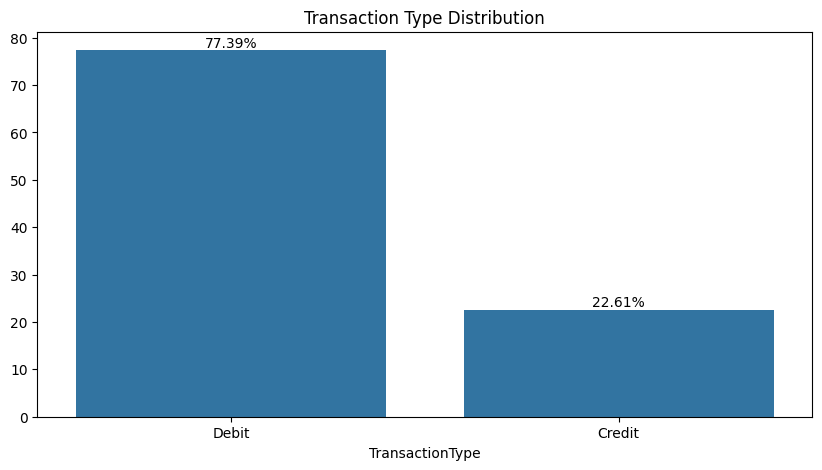

In [353]:
plt.figure(figsize = (10,5))
ax = sns.barplot(x=(df['TransactionType'].value_counts()*100.0/len(df)).index, y= (df['TransactionType'].value_counts()*100.0/len(df)).values)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.title('Transaction Type Distribution')
plt.show()

**Transaction Type Distribution**
- Debit: **~77.39%**
- Credit: **~22.61%**

-> Debit transactions account for the majority (about 3.4 times higher than Credit).
**Insight:**

- Fraud is more likely to occur in Debit transactions (e.g., withdrawals, payments).

- If anomalies are mainly concentrated in Debit → this is reasonable and aligns with typical fraud patterns.

- If Credit shows an unusually high fraud rate → further investigation is required.

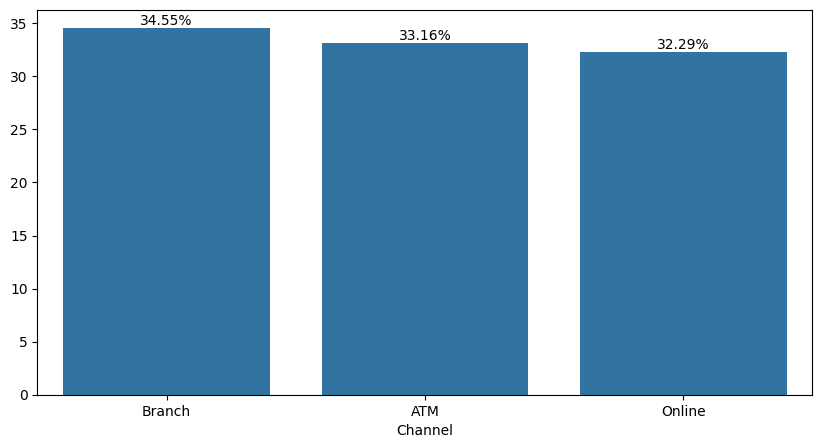

In [355]:
plt.figure(figsize = (10,5))
ax = sns.barplot(x=(df['Channel'].value_counts()*100.0/len(df)).index, y= (df['Channel'].value_counts()*100.0/len(df)).values)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

Channel Distribution (Branch – ATM – Online)

Transaction proportion:

- Branch: **~34.55%**

- ATM: **~33.16%**

- Online: **~32.29%**

The distribution is nearly balanced across all three channels.

**Insight:**

No single channel clearly dominates the transaction volume.

This balanced distribution is ideal for comparing customer behavior and fraud risk across channels.

If the fraud rate differs significantly among the three channels, this variable could become a strong predictive feature for the model.

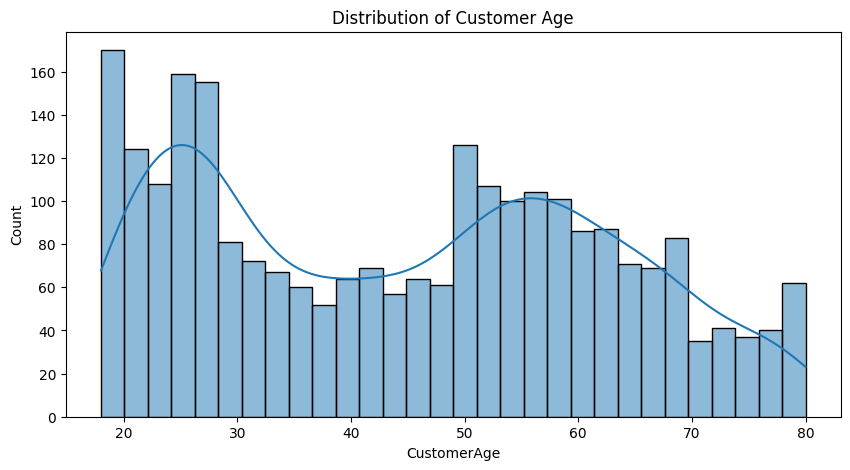

In [356]:
# Distribution of Customer Age
plt.figure(figsize = (10,5))
sns.histplot(df['CustomerAge'], bins=30, kde=True)
plt.title('Distribution of Customer Age')
plt.show()


Distribution of Customer Age
**Observations:**

The age distribution shows two clear peaks:

20–30 years old

50–60 years old

Fewer customers are in the 35–45 age range.

The distribution tail extends up to 80 years old.

**Insight:**

This dataset appears to represent:

A group of young, active users

And a group of middle-aged / retired customers

This structure provides a strong foundation for age-based segmentation, which can improve behavioral analysis and fraud detection modeling (e.g., comparing transaction patterns across age cohorts).

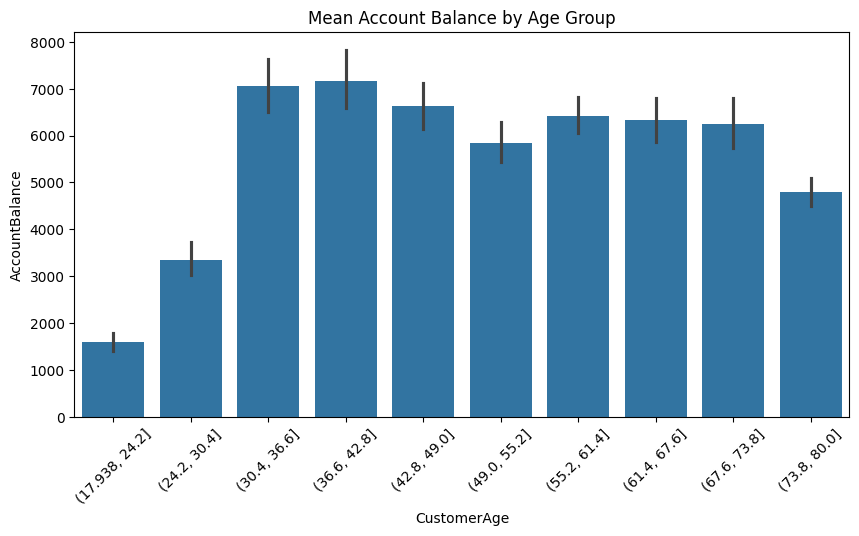

In [362]:
# Mean of Account Balance by Age Group
plt.figure(figsize = (10,5))
sns.barplot(x = pd.cut(df['CustomerAge'], bins=10), y = df['AccountBalance'])
plt.title('Mean Account Balance by Age Group')
plt.xticks(rotation=45)
plt.show()


4️⃣ Mean Account Balance by Age Group (Important)

Observations:

18–24: Low average balance (~1,500)

25–35: Sharp increase (~7,000)

35–45: Remains high (~7,000+)

45–55: Slight decrease

75–80: Significant decline (~4,800)

Strong Business Insight:

This clearly reflects a financial lifecycle pattern:

Age Group	Financial Stage
18–24	Early career, low savings
25–40	Peak earning period
45–60	Financial stability
70+	Retirement drawdown

This is a highly realistic economic pattern, suggesting that the dataset is relatively clean and logically aligned with real-world financial behavior.

From a modeling perspective, this also indicates that age and balance interactions could be meaningful features for behavioral segmentation and fraud risk analysis.

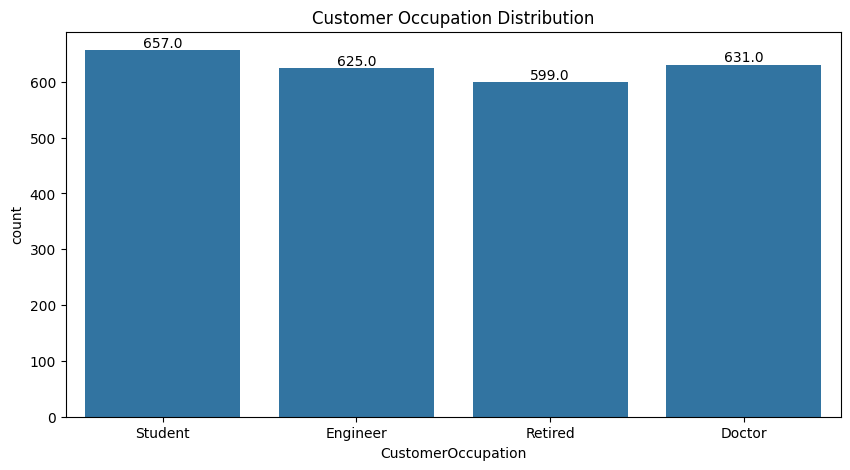

In [360]:
# Customer Occupation do Transaction
plt.figure(figsize = (10,5))
ax = sns.countplot(x = 'CustomerOccupation', data = df)
plt.title('Customer Occupation Distribution')
for p in ax.patches:
    ax.annotate(f'{p.get_height():}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()


Customer Occupation Distribution

The counts are nearly evenly distributed:

Student ~657

Engineer ~625

Retired ~599

Doctor ~631

Insight:

The dataset is well-balanced across occupations → no significant bias toward any specific profession.

If fraud rates differ across occupations, it is likely a genuine behavioral signal rather than a result of data imbalance.

This is a strong advantage for modeling, as it allows fair comparison and more reliable feature importance interpretation.

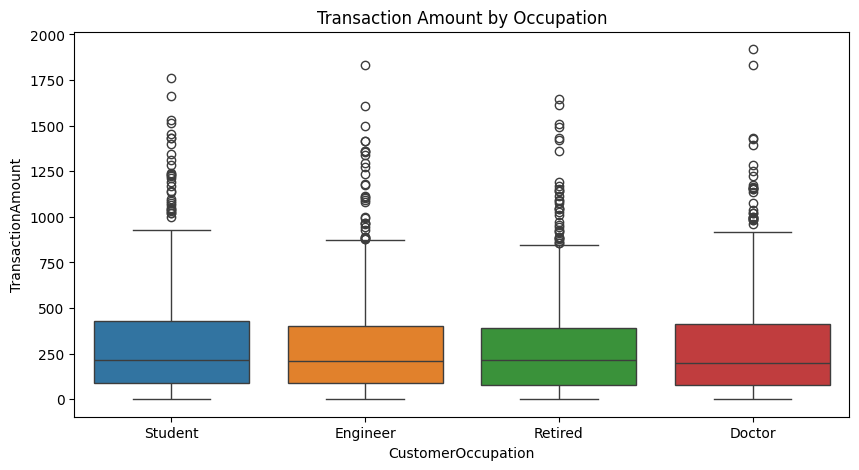

In [363]:
# Sinh viên (Student) có hành vi khác Doctor không?
student_df = df[df['CustomerOccupation'] == 'Student']
doctor_df = df[df['CustomerOccupation'] == 'Doctor']

plt.figure(figsize=(10,5))
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', hue='CustomerOccupation', data=df)
plt.title('Transaction Amount by Occupation')
plt.show()

Transaction Amount by Occupation (Boxplot)

**Observations:**

The median transaction amount is fairly similar across all occupation groups.

Doctor and Engineer show more high-value outliers.

Retired has a slightly narrower spread.

Student tends to have more small-value transactions.

**Business Insight:**

Doctor / Engineer may have:

Higher income levels

Larger average transaction sizes

Student typically shows smaller transactions (small payments, small transfers).

This reflects natural economic behavior differences across occupation groups.

 **Fraud Insight:**

High outliers appear mostly in:

Doctor

Engineer

If the fraud model detects many anomalies in these two groups, it might be due to:

High transaction amounts

Not necessarily truly abnormal behavior

 Therefore, it is important to normalize transaction features by occupation (or use an income proxy feature) to prevent the model from confusing “high spending” with “fraudulent behavior.”

In [365]:
df.head()

,TransactionDate,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap,hour,is_night_hour,Region,amount_log,time_gap_log,balance_log,is_extreme_amount,is_extreme_login,month,day_of_week,hour_sin,hour_cos,day_sin,day_cos,tran_count_1h,tran_count_24h,device_account_count,iso_score,iso_pred,iso_label,PCA1_Iso,PCA2_Iso,lof_score,lof_pred,lof_labels,PCA1_LOF,PCA2_LOF,ocsvm_score,ocsvm_pred,ocsvm_labels,PCA1_OCSVM,PCA2_OCSVM,kmean_pred,kmean_label,cluster,anomaly_vote,final_anomaly,final_anomaly_strict,risk_level,HourOfDay
0,2023-09-15 17:00:20,TX001313,AC00001,47.79,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0,17,0,West,3.887525,0.000000,7.409088,0,0,9,4,-0.965926,-0.258819,-0.433884,-0.900969,0.0,0.0,8,0.039176,1,Normal,-2.939067,0.823758,0.227939,1,Normal,-2.939067,0.823758,0.766438,1,Normal,-2.939067,0.823758,1,Median Risk,1,0,0,0,Low,17
1,2023-11-14 16:56:34,TX002017,AC00001,212.97,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0,16,0,South,5.365836,15.461044,8.338401,0,0,11,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.122961,1,Normal,0.963691,-0.870714,0.270899,1,Normal,0.963691,-0.870714,1.601001,1,Normal,0.963691,-0.870714,2,High Risk,2,1,0,0,Low,16
2,2023-01-10 16:00:32,TX002121,AC00002,476.99,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0,16,0,West,6.169590,0.000000,7.052271,0,0,1,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,4,0.108661,1,Normal,-2.974289,-0.783547,0.312600,1,Normal,-2.974289,-0.783547,1.235361,1,Normal,-2.974289,-0.783547,1,Median Risk,1,0,0,0,Low,16
3,2023-02-28 16:36:58,TX000021,AC00002,59.32,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0,16,0,West,4.099664,15.259080,8.657284,0,0,2,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.093817,1,Normal,0.900762,-0.816353,0.231234,1,Normal,0.900762,-0.816353,0.620768,1,Normal,0.900762,-0.816353,2,High Risk,2,1,0,0,Low,16
4,2023-05-05 16:35:44,TX001477,AC00002,12.62,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0,16,0,West,2.611539,15.556385,8.767402,0,0,5,4,-0.866025,-0.500000,-0.433884,-0.900969,0.0,0.0,2,0.092787,1,Normal,1.001801,-0.733752,0.259923,1,Normal,1.001801,-0.733752,0.640785,1,Normal,1.001801,-0.733752,2,High Risk,2,1,0,0,Low,16


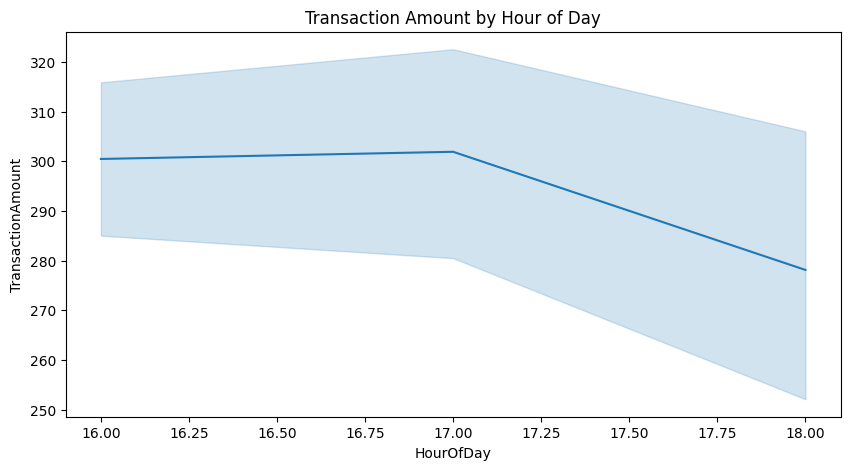

In [364]:
# Transaction Amount by Hour of Day
df['HourOfDay'] = df['TransactionDate'].dt.hour
plt.figure(figsize=(10,5))
sns.lineplot(x='HourOfDay', y='TransactionAmount', data=df)
plt.title('Transaction Amount by Hour of Day')
plt.show()

Transaction Amount by Hour of Day

Observations:

16:00 → ~300

17:00 → peak at ~302

18:00 → drops to ~278

Confidence interval (spread) is relatively wide

Behavioral Insight:

Transaction activity peaks during late working hours (16–17h).

It declines after 18h.

This aligns well with natural human behavior:

After work → transfers, bill payments, withdrawals

Late evening → reduced activity

This pattern appears realistic and economically logical.

Fraud Implication:

If we observe:

High transaction amounts at 2–4 AM,

Or unusual spikes outside this normal daily pattern,

→ That would represent a strong anomaly signal.

From a modeling perspective, this means that hour-of-day features (or time-based deviation from normal behavior) could significantly improve anomaly detection performance.

In [368]:
df['day_of_week'].value_counts()

day_of_week
0    1070
4     373
3     368
1     360
2     341
Name: count, dtype: int64

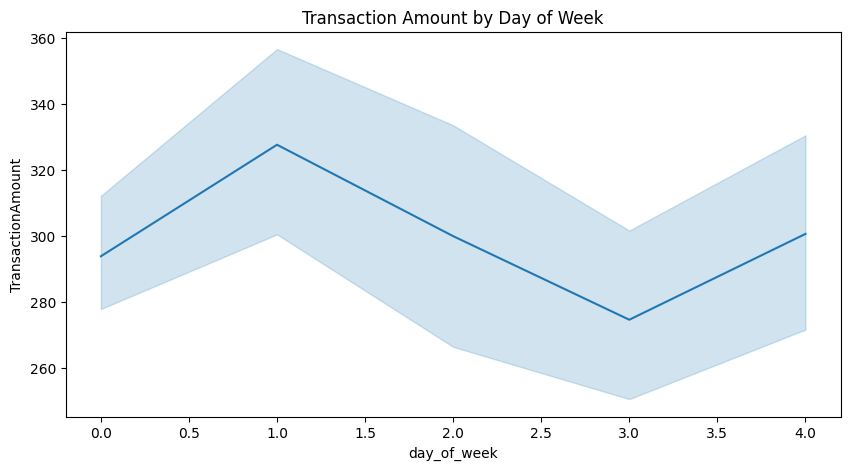

In [367]:
plt.figure(figsize = (10,5))
sns.lineplot(x = 'day_of_week', y = 'TransactionAmount', data = df)
plt.title('Transaction Amount by Day of Week')
plt.show()

**Transaction Amount by Day of Week**

**Observations:**

Day 1 (possibly Tuesday) is the highest at ~327

Day 3 is the lowest at ~275

Overall fluctuation is moderate

**Behavioral Insight:**

There appears to be a weekly cycle pattern.

Some days consistently show higher transaction amounts.

**Depending on the mapping:**

If Day 1 = Monday → this could reflect a salary cycle effect.

If Day 5 = Friday → it may relate to pre-weekend spending behavior.

This suggests realistic weekly financial behavior.

**Fraud Implication:**

**Fraud activity often increases:**

During weekends

During night hours

On holidays or non-working days

If your anomaly detection model identifies a high concentration of anomalies during:

Weekend days

Off-hours

→ That would be logically consistent with real-world fraud patterns.

This means combining day-of-week + hour-of-day features can significantly strengthen fraud detection signals.

In [371]:
df['month'].value_counts().sort_index()

month
1     220
2     218
3     197
4     161
5     220
6     212
7     195
8     224
9     214
10    226
11    221
12    204
Name: count, dtype: int64

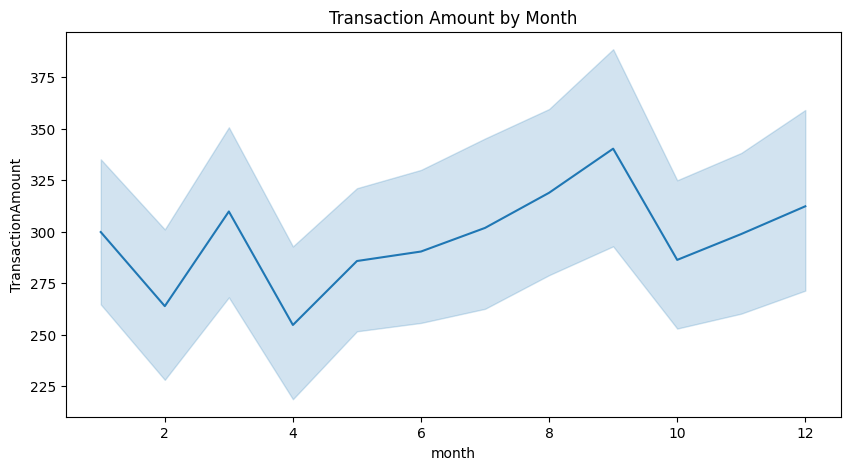

In [369]:
plt.figure(figsize = (10,5))
sns.lineplot(x='month', y='TransactionAmount', data=df)
plt.title('Transaction Amount by Month')
plt.show()

**Transaction Amount by Month**

**Observations:**

September shows the highest average (~340).

April is the lowest (~255).

There is a gradual increase from June → September.

A drop appears in October, followed by another increase.

**Insight:**

There appears to be a seasonal pattern in transaction amounts.

This could be due to:

Higher economic activity during Q3,

Or a simulated trend embedded in the dataset.

The pattern looks structured rather than random noise.

**Fraud Implication:**

If the model does not properly account for seasonality,

→ It may incorrectly interpret September transactions as anomalies simply because amounts are higher during that period.

To avoid this, consider:

Seasonal normalization (e.g., month-level scaling),

Including Month as a feature in the model,

Or using rolling baseline comparisons instead of global thresholds.

### Univariate Analysis

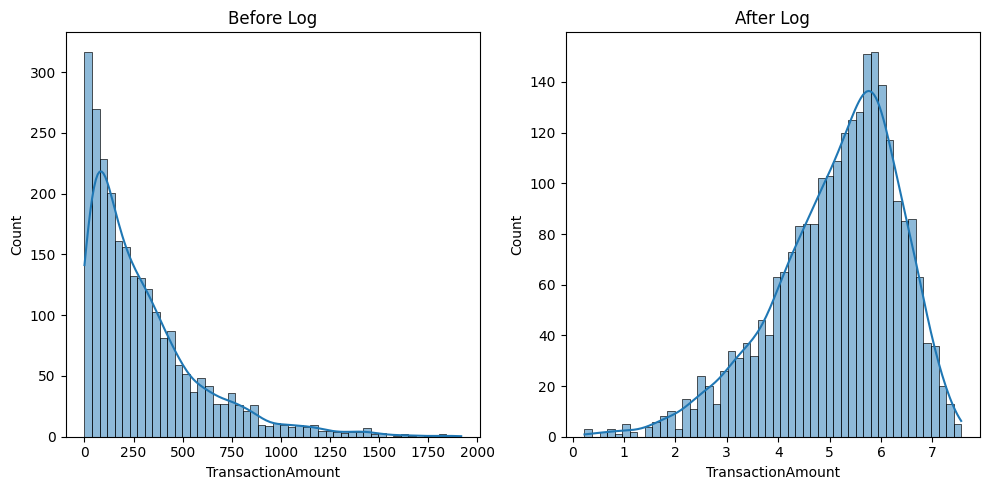

In [262]:

fig,axes = plt.subplots(1,2, figsize= (10,5))
# Before Log
sns.histplot(df['TransactionAmount'], bins=50, kde = True, ax = axes[0])
axes[0].set_title('Before Log')
# After Log
sns.histplot(np.log1p(df['TransactionAmount']), bins= 50, kde=True, ax = axes[1])
axes[1].set_title('After Log')

plt.tight_layout()
plt.show()

**TransactionAmount – Before vs After Log Transformation**

**Before Log**

Strong right-skewed distribution

Many small-value transactions

A few very large outliers (~2000)

This is a typical financial data distribution.

**Problem:**

Distance-based models (KMeans, LOF, One-Class SVM) may be dominated by large outliers.

Isolation Forest may easily flag high-amount transactions as anomalies, even if they are legitimate high-income behavior.

This creates a bias toward magnitude rather than true abnormality.

**After Log Transformation**

Distribution becomes closer to Gaussian

More symmetric

Extreme values are compressed

This is a standard and appropriate preprocessing step for fraud datasets.

From a modeling perspective, log transformation:

Reduces scale distortion

Improves distance stability

Helps anomaly models focus on behavioral deviation instead of raw magnitude

This significantly improves anomaly detection robustness.

In [372]:
# Top 1% Transaction Amount
top_1_percent = df['TransactionAmount'].quantile(0.99)
print('Top 1% Transaction Amount: ', top_1_percent)

Top 1% Transaction Amount:  1360.5973999999999


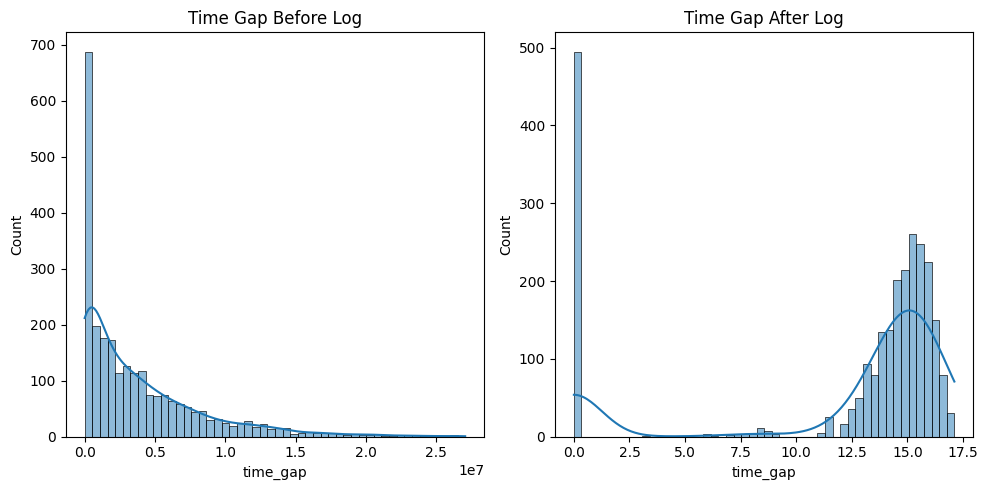

In [263]:
# Time gap: Before and After Log
fig, axes = plt.subplots(1,2,figsize = (10,5))
sns.histplot(df['time_gap'], bins = 50, kde= True, ax = axes[0])
axes[0].set_title('Time Gap Before Log')

sns.histplot(np.log1p(df['time_gap']), bins = 50, kde = True, ax = axes[1])
axes[1].set_title('Time Gap After Log')

plt.tight_layout()
plt.show()

**Time Gap – Before vs After Log**

**Before Log**

Extremely right-skewed distribution

Many transactions have very small time gaps

Some gaps are extremely large

**This is very typical user behavior:**

Users perform multiple transactions consecutively

Then remain inactive for a long period

**After Log**

Distribution becomes more stable and closer to normal

Clear separation between:

Very small gaps

Medium gaps

Long gaps

**This transformation helps the model distinguish between:**

Normal frequent usage

Dormant accounts

Sudden activity spikes

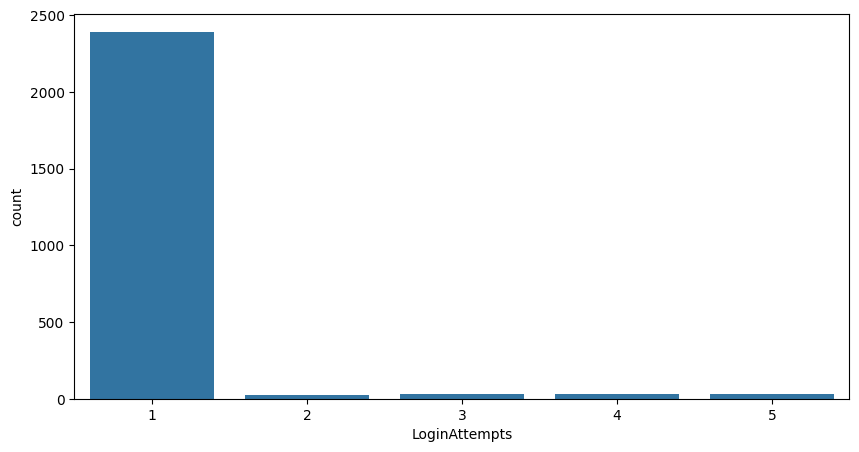

In [264]:
# Login Attempts Distribution
plt.figure(figsize = (10,5))
sns.countplot(x = 'LoginAttempts', data = df)
plt.show()

**LoginAttempts Distribution**

**Observations:**

LoginAttempts = 1 accounts for almost all transactions.

Values from 2–5 are very rare.

**Insight:**

The dataset is highly imbalanced in terms of login attempts.

Multiple login attempts represent rare behavior.

**In real-world fraud scenarios:**

Multiple login attempts may indicate brute force attacks or account takeover attempts.

However, because this behavior is rare in the dataset, the model might classify it as an anomaly simply due to rarity rather than actual risk.

**Important consideration:**

Rare does not necessarily mean Fraud.

The model should evaluate login attempts in combination with other signals (e.g., transaction amount, time gap, unusual channel, off-hour activity) instead of treating rarity alone as a strong fraud indicator.

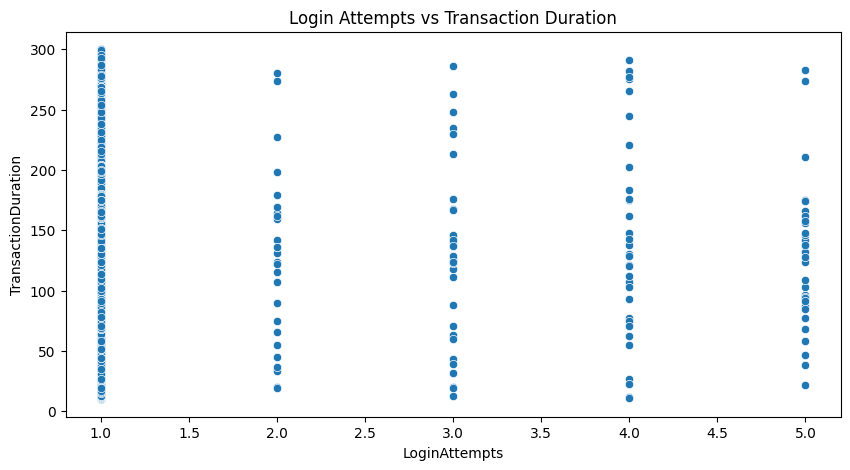

In [373]:
# Login Attempts vs TransactionDuration
plt.figure(figsize = (10,5))
sns.scatterplot(x = 'LoginAttempts', y = 'TransactionDuration', data = df)
plt.title('Login Attempts vs Transaction Duration')
plt.show()



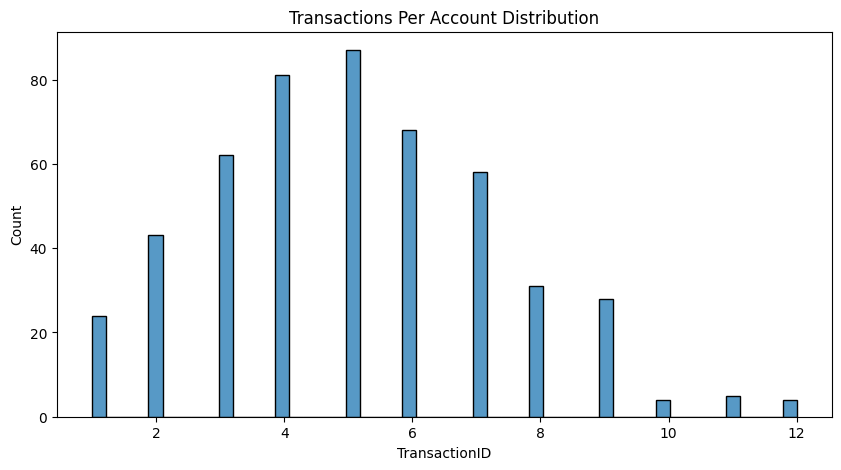

In [374]:
# Transaction Per Account
tran_per_account = df.groupby('AccountID')['TransactionID'].count()
plt.figure(figsize = (10,5))
sns.histplot(tran_per_account, bins = 50)
plt.title('Transactions Per Account Distribution')
plt.show()


### Bivariate Analysis

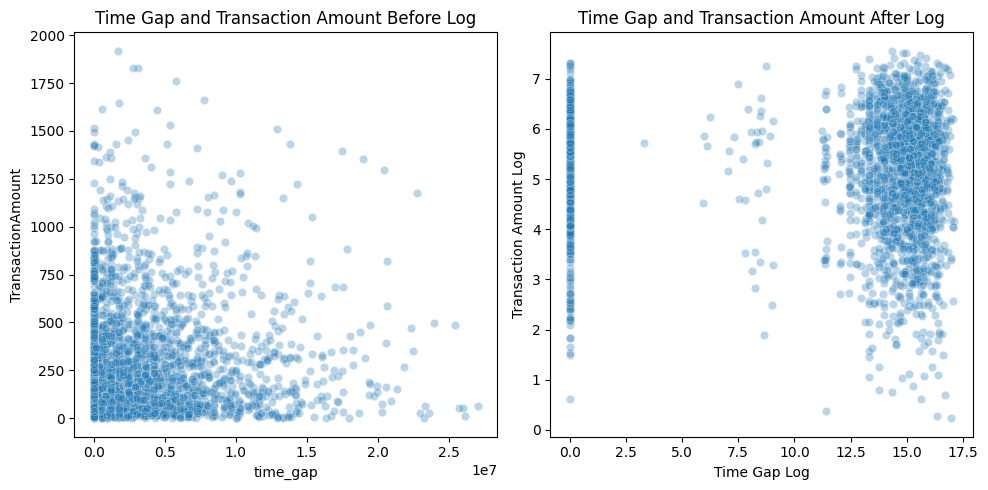

In [266]:
# TransactionAmount vs Time Gap
fig ,axes = plt.subplots(1,2, figsize = (10,5))
sns.scatterplot(
    data = df,
    x = 'time_gap',
    y = 'TransactionAmount',
    alpha = 0.3,
    ax = axes[0]
)
sns.scatterplot(
    x = np.log1p(df['time_gap']),
    y = np.log1p(df['TransactionAmount']),
    alpha = 0.3,
    ax = axes[1]
)
plt.xlabel('Time Gap Log')
plt.ylabel('Transaction Amount Log')
axes[1].set_title('Time Gap and Transaction Amount After Log')
axes[0].set_title('Time Gap and Transaction Amount Before Log')
plt.tight_layout()
plt.show()

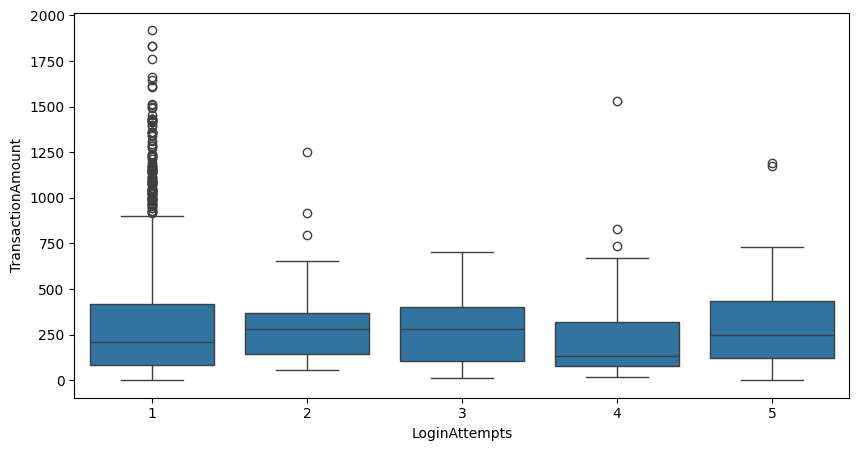

In [267]:
# Login Attemps vs Amount 
plt.figure(figsize = (10,5))
sns.boxplot(x = 'LoginAttempts', y = 'TransactionAmount', data = df)
plt.show()

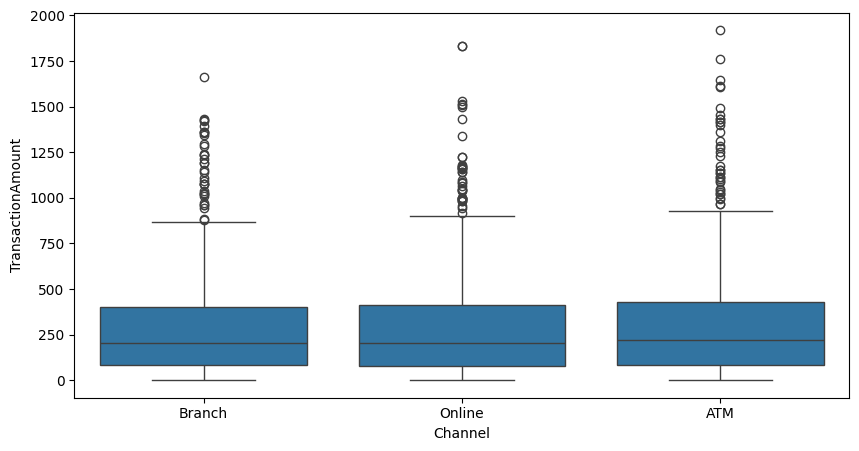

In [340]:
# Boxplot of Transaction Amount by Channel
plt.figure(figsize = (10,5))
sns.boxplot(x = 'Channel', y = 'TransactionAmount', data = df)
plt.show()

**Boxplot – Transaction Amount by Channel**

**Observations:**

The median transaction amount is relatively similar across all three channels.

**However:**

- ATM shows a higher number of large outliers.

- Online also contains several extreme values.

- Branch transactions appear slightly lower and more stable.

**Advanced Insight:**

**A high number of outliers is observed in:**

ATM → possibly due to unusually large cash withdrawals.

Online → potentially linked to fraudulent payment activities.

These extreme values are exactly the type of patterns that models like Isolation Forest and Local Outlier Factor (LOF) are designed to detect as anomalies.

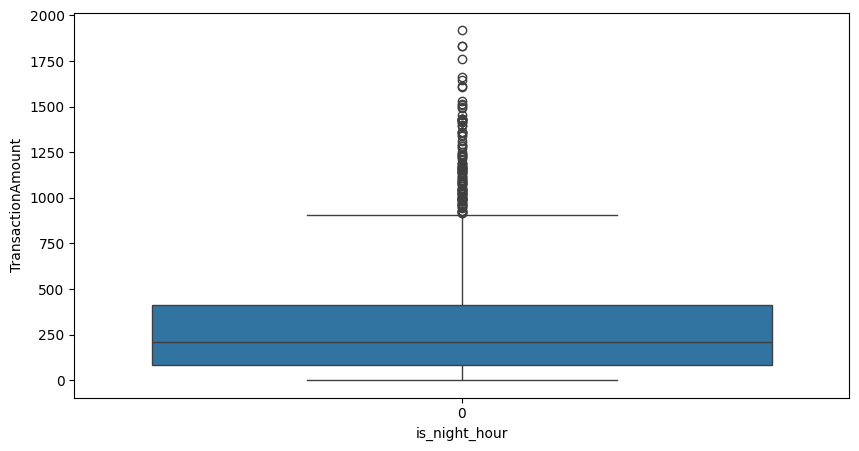

In [268]:
# Night Transaction vs Amount
df['hour'] = df['TransactionDate'].dt.hour
df['is_night_hour'] = df['hour'].between(0,5).astype(int)

plt.figure(figsize=(10,5))
sns.boxplot(x = 'is_night_hour', y = 'TransactionAmount', data = df)
plt.show()

### Multivariate Analysis

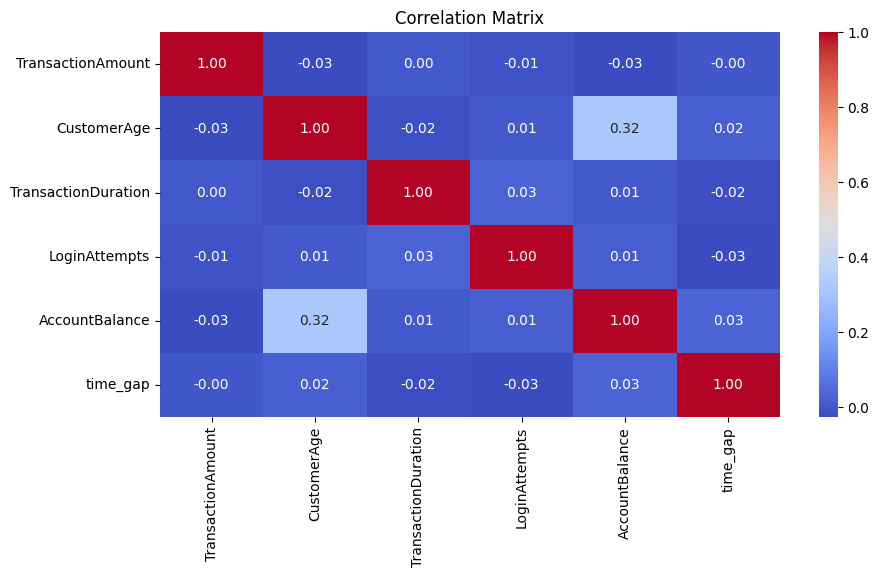

In [269]:
multi_num = [
    'TransactionAmount', 'CustomerAge', 'TransactionDuration','LoginAttempts', 'AccountBalance','time_gap'
]
corr_matrix = df[multi_num].corr()
plt.figure(figsize = (10,5))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()

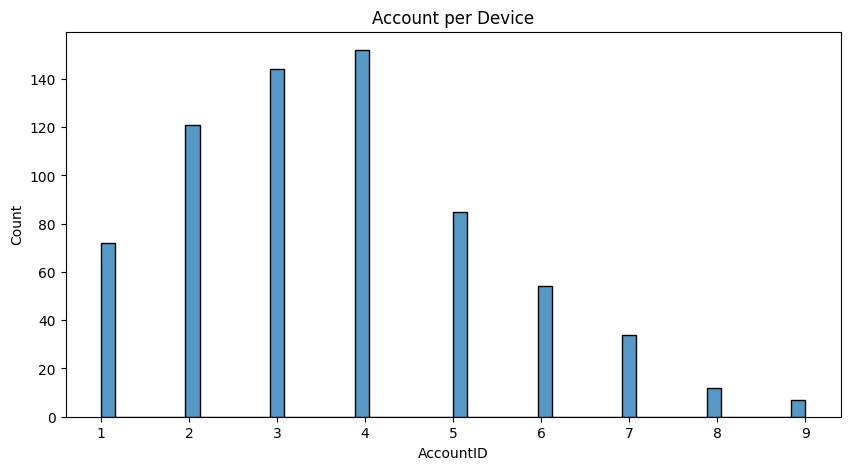

In [270]:
# Device Sharing Risk
device_account = df.groupby('DeviceID')['AccountID'].nunique()
plt.figure(figsize=(10,5))
sns.histplot(device_account, bins = 50)
plt.title('Account per Device')
plt.show()

# Feature Engineering

In [271]:
df.info()

<class 'pandas.DataFrame'>
Index: 2512 entries, 1312 to 2349
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   str           
 1   AccountID                2512 non-null   str           
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[us]
 4   TransactionType          2512 non-null   str           
 5   Location                 2512 non-null   str           
 6   DeviceID                 2512 non-null   str           
 7   IP Address               2512 non-null   str           
 8   MerchantID               2512 non-null   str           
 9   Channel                  2512 non-null   str           
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   str           
 12  TransactionDuration      2512 non-null   int64 

In [272]:
# Mapping city -> region
region_map = {
    # Northeast
    "New York": "Northeast",
    "Philadelphia": "Northeast",
    "Boston": "Northeast",
    
    # Midwest
    "Chicago": "Midwest",
    "Detroit": "Midwest",
    "Columbus": "Midwest",
    "Indianapolis": "Midwest",
    "Milwaukee": "Midwest",
    "Omaha": "Midwest",
    "Kansas City": "Midwest",
    
    # South
    "Dallas": "South",
    "Houston": "South",
    "San Antonio": "South",
    "Austin": "South",
    "Fort Worth": "South",
    "Charlotte": "South",
    "Memphis": "South",
    "Atlanta": "South",
    "Miami": "South",
    "Virginia Beach": "South",
    "Nashville": "South",
    "Louisville": "South",
    "Oklahoma City": "South",
    "Baltimore": "South",
    "Washington": "South",
    "Jacksonville": "South",
    "Raleigh": "South",
    
    # West
    "Los Angeles": "West",
    "San Diego": "West",
    "San Jose": "West",
    "San Francisco": "West",
    "Seattle": "West",
    "Portland": "West",
    "Phoenix": "West",
    "Las Vegas": "West",
    "Denver": "West",
    "Albuquerque": "West",
    "Fresno": "West",
    "Sacramento": "West",
    "Mesa": "West",
    "Colorado Springs": "West",
    "Tucson": "West",
    "El Paso": "West",
}

# Apply mapping
df["Region"] = df["Location"].map(region_map)

In [273]:
# Check outliers
check_col = df.select_dtypes(include=['int64','float64']).columns.to_list
check_col

<bound method IndexOpsMixin.tolist of Index(['TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'time_gap', 'is_night_hour'],
      dtype='str')>

In [274]:
outlier_col = [
    'TransactionAmount', 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance'
]
Q1 = df[outlier_col].quantile(0.25)
Q3 = df[outlier_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = ((df[outlier_col] < lower_bound) | (df[outlier_col] > upper_bound))
print(outliers.sum())

TransactionAmount      113
CustomerAge              0
TransactionDuration      0
LoginAttempts          122
AccountBalance           0
dtype: int64


In [275]:
# Log Transformation Amount/Time_gap/AccountBalance
df['amount_log'] = np.log1p(df['TransactionAmount'])
df['time_gap_log'] = np.log1p(df['time_gap'])
df['balance_log'] = np.log1p(df['AccountBalance'])


- Transform TransactionAmount/time_gap/AmountBalance: -> skewness data 

In [276]:
# Extreme Behavior Flags
amount_99 = df['TransactionAmount'].quantile(0.99)
login_99 = df['LoginAttempts'].quantile(0.99)

df['is_extreme_amount'] = (df['TransactionAmount'] > amount_99).astype(int)
df['is_extreme_login'] = (df['LoginAttempts'] > login_99).astype(int)


- When fraud occurs:
    - Transaction too big
    - Anomaly Login Attempts
-> Mark data instead of models have to self-understand
- Using 99% quantile:
    - Not depend on Distribution
    - Not affect by outliers
    - Dynamic theo datset
- is_extreme_amount = 1 -> top 1% giao dịch lớn nhất
- is_extreme_login = 1 -> hành vi login bất thường

In [277]:
# Convert to Datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
# Sort Values
df = df.sort_values(['AccountID','TransactionDate'])

# Time-based Features (Time_Gap)

# Hour/Month/DayofWeek
df['hour'] = df['TransactionDate'].dt.hour
df['month'] = df['TransactionDate'].dt.month
df['day_of_week'] = df['TransactionDate'].dt.dayofweek

# Cyclical Encoding x(sin) = sin((2*pi*t)/T), x(cos) = cos((2*pi*t)/T)
df['hour_sin'] = np.sin(2*np.pi*df['hour']/ 24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/ 24)

df['day_sin'] = np.sin(2*np.pi*df['day_of_week']/ 7)
df['day_cos'] = np.cos(2*np.pi*df['day_of_week']/ 7)

# Rolling Frequency Features
df = df.set_index('TransactionDate')

df['tran_count_1h'] = (
    df.groupby('AccountID')['TransactionID']
    .rolling('1h')
    .count()
    .reset_index(level = 0, drop = True)
)
df['tran_count_24h'] = (
    df.groupby('AccountID')['TransactionID']
    .rolling('24h')
    .count()
    .reset_index(level = 0, drop = True)
)
# Fix null values (except the current transaction)
df[['tran_count_1h']] -= 1
df[['tran_count_24h']] -= 1
df = df.reset_index()
# Device Risk Features
device_risk = df.groupby('DeviceID')['AccountID'].nunique()
df['device_account_count'] = df['DeviceID'].map(device_risk)

- Fraud has pattern following time:
    - transaction at 2-4 am
    - in the weekend
    - the the end of month
    - in occasion/event
-> Time = Bevahioral signal
- Cyclical Encoding:
    - Hour has circular(chu kì)-> 23h and 0h are pretty close if it is a `int` -> 0 and 23 is too far -> wrong
    - Sin/Cos Encoding -> keep the circular and model can understand the amount of time.
- Rolling Frequency Features: how many transactions in 1h or 24h
- Fraudter usually:
    - use 1 device -> login many accounts
    - or 1 IP -> many accounts

Group	             Type of Signal

Log transform	  ->  Distribution correction

Extreme flag	    -> Outlier behavior

Time encoding	    -> Temporal pattern

Rolling freq	    -> Behavioral burst

Device risk	        -> Network risk

In [278]:
df.head()

,TransactionDate,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap,hour,is_night_hour,Region,amount_log,time_gap_log,balance_log,is_extreme_amount,is_extreme_login,month,day_of_week,hour_sin,hour_cos,day_sin,day_cos,tran_count_1h,tran_count_24h,device_account_count
0,2023-09-15 17:00:20,TX001313,AC00001,47.79,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0,17,0,West,3.887525,0.000000,7.409088,0,0,9,4,-0.965926,-0.258819,-0.433884,-0.900969,0.0,0.0,8
1,2023-11-14 16:56:34,TX002017,AC00001,212.97,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0,16,0,South,5.365836,15.461044,8.338401,0,0,11,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1
2,2023-01-10 16:00:32,TX002121,AC00002,476.99,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0,16,0,West,6.169590,0.000000,7.052271,0,0,1,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,4
3,2023-02-28 16:36:58,TX000021,AC00002,59.32,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0,16,0,West,4.099664,15.259080,8.657284,0,0,2,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1
4,2023-05-05 16:35:44,TX001477,AC00002,12.62,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0,16,0,West,2.611539,15.556385,8.767402,0,0,5,4,-0.866025,-0.500000,-0.433884,-0.900969,0.0,0.0,2


In [279]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionDate          2512 non-null   datetime64[us]
 1   TransactionID            2512 non-null   str           
 2   AccountID                2512 non-null   str           
 3   TransactionAmount        2512 non-null   float64       
 4   TransactionType          2512 non-null   str           
 5   Location                 2512 non-null   str           
 6   DeviceID                 2512 non-null   str           
 7   IP Address               2512 non-null   str           
 8   MerchantID               2512 non-null   str           
 9   Channel                  2512 non-null   str           
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   str           
 12  TransactionDuration      2512 non-null   int6

In [280]:
num_features = [ 'CustomerAge', 'TransactionDuration',
       'LoginAttempts', 'is_night_hour', 'amount_log', 'time_gap_log',
        'balance_log', 'is_extreme_amount',
       'is_extreme_login', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'tran_count_1h', 'tran_count_24h', 'device_account_count']
cate_features =['TransactionType', 'Region', 'Channel', 'CustomerOccupation'
]           


In [284]:
# Skew check 
for col in num_features:
    print(col, 'Skew: ', skew(df[col]))

CustomerAge Skew:  0.1477760713709111
TransactionDuration Skew:  0.5990738033681695
LoginAttempts Skew:  5.170400738779346
is_night_hour Skew:  nan
amount_log Skew:  -0.803321903617277
time_gap_log Skew:  -1.3723977557500138
balance_log Skew:  -0.8025105948111522
is_extreme_amount Skew:  9.676044810942395
is_extreme_login Skew:  nan
hour_sin Skew:  -0.2148196206112655
hour_cos Skew:  0.763771499340941
day_sin Skew:  0.24610603779694043
day_cos Skew:  -0.38249335831315445
tran_count_1h Skew:  12.409931919894252
tran_count_24h Skew:  7.371415750919391
device_account_count Skew:  0.34966046750776514


- Normal Features: Skew < 0.5
    - `CustomerAge`, `hour_sin `,  `day_sin `, `day_cos `, `device_account_count`
    - `amount_log `, `time_gap_log `, `balance_log ` -> Negative Columns

    -> These columns are not need to be transformed

- Morderate features: 0.5 < Skew < 1
    - `TransactionDuration`, `hour_cos`

    -> Try yeo-johnson
- Large Skew features: Skew > 1
    - `LoginAttempts`, `is_extreme_amount`, `tran_count_1h`, `tran_count_24h`

    -> Strongly skew

In [285]:
# Log Transformation for count Features: 'LoginAttempts', 'tran_count_1h','tran_count_24h'
count_features = [
    'LoginAttempts',
    'tran_count_1h',
    'tran_count_24h'
]
count_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', RobustScaler())
])

In [286]:
# Power Transform for Morderate/Negative Skew: 'TransactionDuration','amount_log', 'time_gap_log','balance_log','hour_cos'
power_features = [
    'TransactionDuration',
    'amount_log',
    'time_gap_log',
    'balance_log',
    'hour_cos'
]
power_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', RobustScaler())
])

In [287]:
# Normal Features -> scale: 'CustomerAge', 'device_account_count',`hour_sin`,  `day_sin`, `day_cos`
normal_features = [
    'CustomerAge',
    'device_account_count',
    'hour_sin',
    'day_sin',
    'day_cos'
]
stable_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])


In [288]:
# Binary Features;
binary_features = [
    'is_night_hour',
    'is_extreme_login',
    'is_extreme_amount'
]
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy= 'most_frequent'))
])

In [289]:
# Columns Transformer:
preprocessor = ColumnTransformer(
    transformers=[
        ('log', count_transformer,count_features),
        ('power', power_transformer,power_features),
        ('stable', stable_transformer, normal_features),
        ('binary', binary_transformer, binary_features)
    ], remainder='drop'
)

In [290]:
# Select features 
select_features = (count_features + power_features + normal_features + binary_features)
X = df[select_features].copy()
X_processed = preprocessor.fit_transform(X)


### Model Pipelines


In [291]:
# Isolation Forest:
iso_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', IsolationForest(
        n_estimators= 300,
        contamination=0.02,
        random_state= 42
    ))
])
# Isolation Forest Fit
iso_pipeline.fit(X)
# Get anomaly score (decision_function)
iso_model = iso_pipeline.named_steps['model']
X_processed_iso = iso_pipeline.named_steps['preprocessing'].transform(X)

df['iso_score'] = iso_model.decision_function(X_processed_iso)
df['iso_pred'] = iso_model.predict(X_processed_iso)

# Map label: 1 for normal, -1 for Potential Fraud
df['iso_label'] = df['iso_pred'].map({1:'Normal', -1:'Potential Fraud'})

print('Isolation Forest anomalies: ',(df['iso_label'] == 'Potential Fraud').sum())



Isolation Forest anomalies:  51


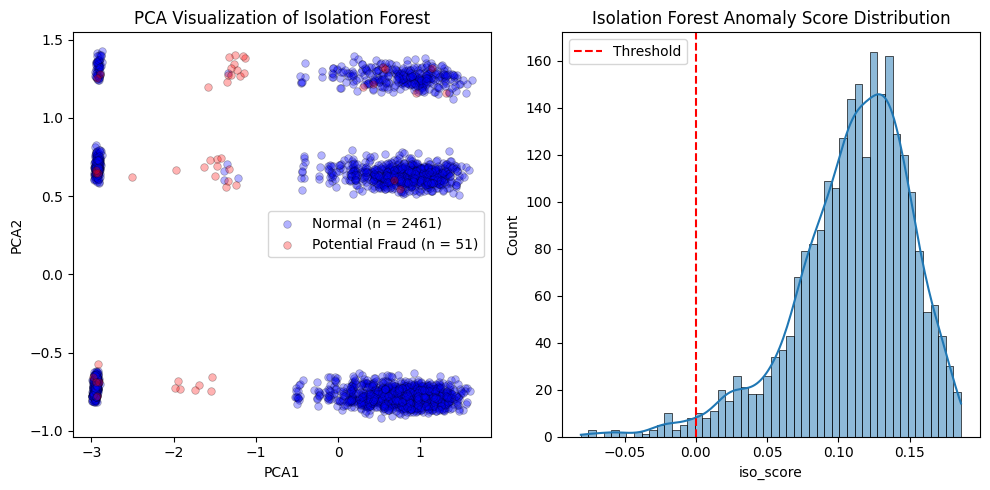

In [292]:
# PCA Visulaization for Isolation Forest
pca = PCA(n_components = 2, random_state= 42)
X_pca = pca.fit_transform(X_processed_iso)
df['PCA1_Iso'] = X_pca[:,0]
df['PCA2_Iso'] = X_pca[:,1]

threshold = 0
normal_df = df[df['iso_label'] == 'Normal']
anomaly_df = df[df['iso_label'] == 'Potential Fraud']

fig, ax = plt.subplots(1,2,figsize = (10,5))

#PCA Scatter plot
ax[0].scatter(normal_df['PCA1_Iso'],
              normal_df['PCA2_Iso'],
              s = 30, alpha = 0.3, label = f'Normal (n = {len(normal_df)})',
              color = 'blue', linewidth = 0.5, edgecolor = 'k')
ax[0].scatter(anomaly_df['PCA1_Iso'],
              anomaly_df['PCA2_Iso'],
              s = 30, alpha = 0.3, label = f'Potential Fraud (n = {len(anomaly_df)})',
              color = 'red', linewidth = 0.5, edgecolor = 'k')
ax[0].set_title('PCA Visualization of Isolation Forest')
ax[0].set_xlabel('PCA1')
ax[0].set_ylabel('PCA2')
ax[0].legend()
# Decision Function Distribution
sns.histplot(df['iso_score'], bins = 50, kde = True, ax = ax[1])
ax[1].set_title('Isolation Forest Anomaly Score Distribution')
ax[1].axvline(x = threshold, color = 'red', linestyle = '--', label = 'Threshold')
ax[1].legend()
plt.tight_layout()
plt.show()


# Isolation Forest - Overall Fraud Detection Summary:
**Cluster Chart**
    - PCA scatter plot shows a separation between normal(blue) and potential fraud (red)

In [293]:
df.head()

,TransactionDate,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap,hour,is_night_hour,Region,amount_log,time_gap_log,balance_log,is_extreme_amount,is_extreme_login,month,day_of_week,hour_sin,hour_cos,day_sin,day_cos,tran_count_1h,tran_count_24h,device_account_count,iso_score,iso_pred,iso_label,PCA1_Iso,PCA2_Iso
0,2023-09-15 17:00:20,TX001313,AC00001,47.79,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0,17,0,West,3.887525,0.000000,7.409088,0,0,9,4,-0.965926,-0.258819,-0.433884,-0.900969,0.0,0.0,8,0.039176,1,Normal,-2.939067,0.823758
1,2023-11-14 16:56:34,TX002017,AC00001,212.97,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0,16,0,South,5.365836,15.461044,8.338401,0,0,11,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.122961,1,Normal,0.963691,-0.870714
2,2023-01-10 16:00:32,TX002121,AC00002,476.99,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0,16,0,West,6.169590,0.000000,7.052271,0,0,1,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,4,0.108661,1,Normal,-2.974289,-0.783547
3,2023-02-28 16:36:58,TX000021,AC00002,59.32,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0,16,0,West,4.099664,15.259080,8.657284,0,0,2,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.093817,1,Normal,0.900762,-0.816353
4,2023-05-05 16:35:44,TX001477,AC00002,12.62,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0,16,0,West,2.611539,15.556385,8.767402,0,0,5,4,-0.866025,-0.500000,-0.433884,-0.900969,0.0,0.0,2,0.092787,1,Normal,1.001801,-0.733752


# Analysis Normal/Potential Fraud:
    - TransactionAmount/CustomerAge/TransactionDuration/Account Balance (Boxplot)
    - TransactionType/CustomerOccupation/Channel/Region (Bar Chart)
    - Month_trend - TransactionAmount (LineChart)
    

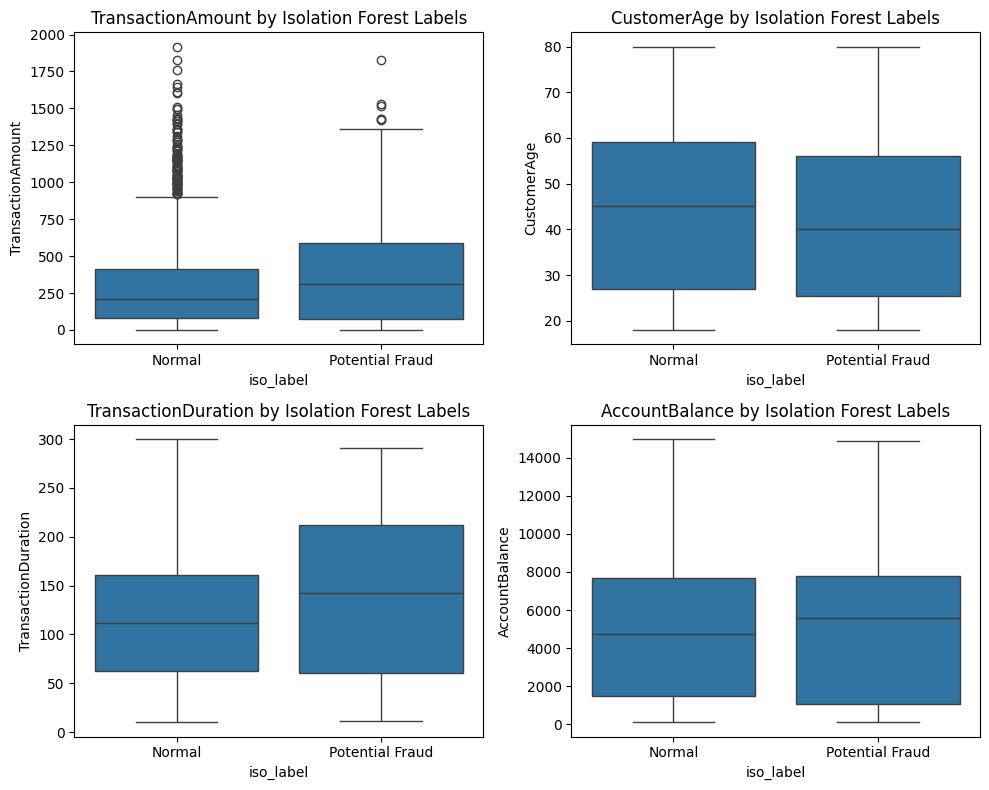

In [294]:
# Analyze feature distribution by Isolation Forest Labels
feature_boxplot = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()

for i, feature in enumerate(feature_boxplot):
    sns.boxplot(x = 'iso_label', y = feature, data = df, ax=axes[i])
    axes[i].set_title(f'{feature} by Isolation Forest Labels')

plt.tight_layout()
plt.show()


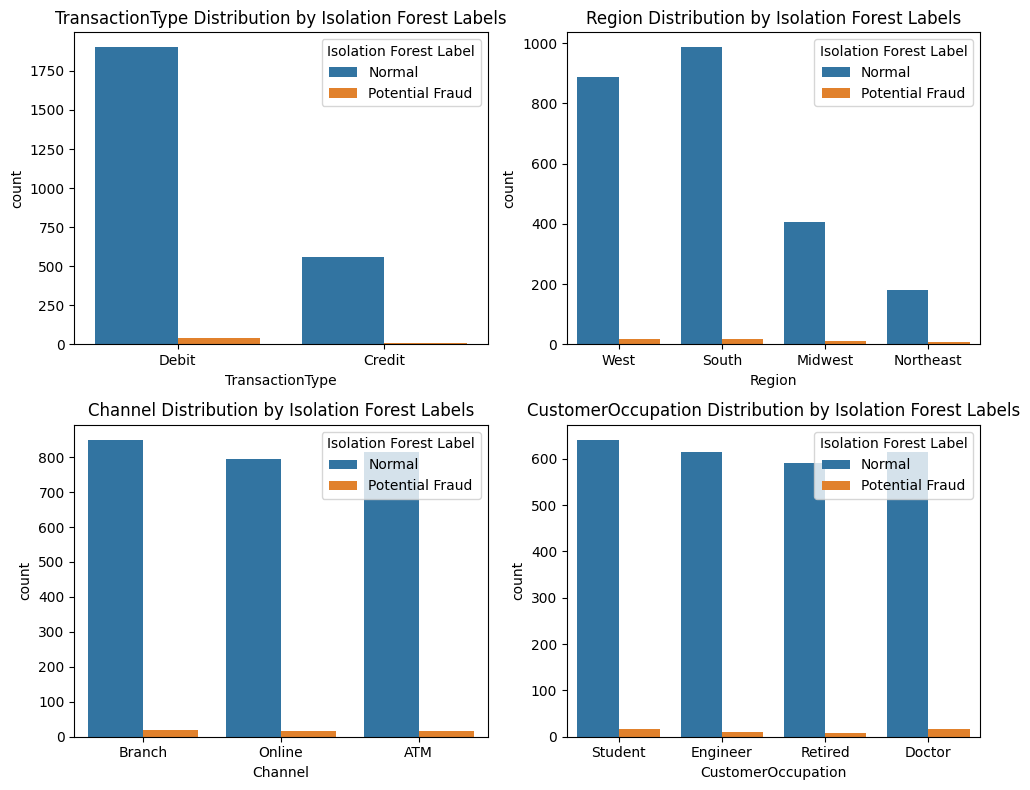

In [295]:
feature_bar = ['TransactionType', 'Region', 'Channel', 'CustomerOccupation']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_bar):
    sns.countplot(x = feature, hue = 'iso_label', data = df, ax = axes[i])
    axes[i].set_title(f'{feature} Distribution by Isolation Forest Labels')
    axes[i].legend(title = 'Isolation Forest Label')
plt.tight_layout()
plt.show()


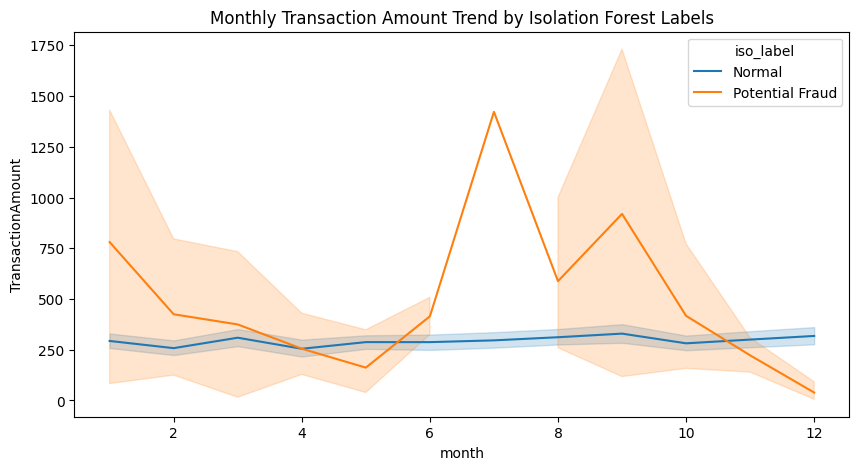

In [296]:
# Trend of transaction Amount by Month
plt.figure(figsize = (10,5))
sns.lineplot(x = 'month', y = 'TransactionAmount', data = df, hue = 'iso_label')
plt.title('Monthly Transaction Amount Trend by Isolation Forest Labels')
plt.show()


In [297]:
# LOF: Local Outlier Factor
lof_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LocalOutlierFactor(
        n_neighbors= 20,
        contamination=0.02, 
        novelty= True
    ))
])
# Fit LOF
lof_pipeline.fit(X)
# Get LOF Score and Prediction
lof_model = lof_pipeline.named_steps['model']
X_processed_lof = lof_pipeline.named_steps['preprocessing'].transform(X)

df['lof_score'] = lof_model.decision_function(X_processed_lof)
df['lof_pred'] = lof_model.predict(X_processed_lof)

df['lof_labels'] = df['lof_pred'].map({1:'Normal', -1:'Potential Fraud'})
print('LOF anomalies: ',(df['lof_labels'] == 'Potential Fraud').sum())

LOF anomalies:  39


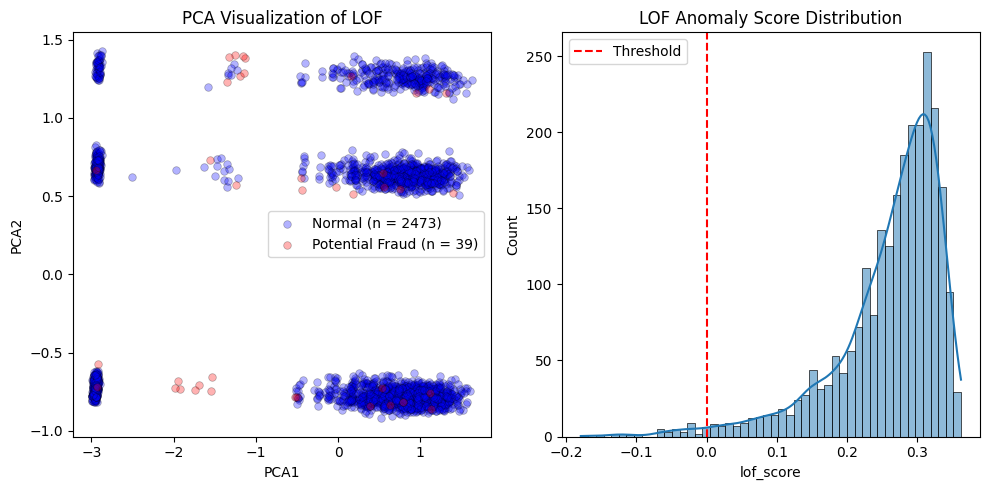

In [298]:
# PCA Visualization for LOF
pca_lof = PCA(n_components=2, random_state= 42)
X_pca_lof = pca_lof.fit_transform(X_processed_lof)
df['PCA1_LOF'] = X_pca_lof[:,0]
df['PCA2_LOF'] = X_pca_lof[:,1]

normal_df_lof = df[df['lof_labels'] == 'Normal']
anomaly_df_lof = df[df['lof_labels'] == 'Potential Fraud']

fig, ax = plt.subplots(1,2,figsize = (10,5))
#PCA Scatter plot
ax[0].scatter(normal_df_lof['PCA1_LOF'],
              normal_df_lof['PCA2_LOF'],
              s = 30, alpha = 0.3, label = f'Normal (n = {len(normal_df_lof)})',
              color = 'blue', linewidth = 0.5, edgecolor = 'k')
ax[0].scatter(anomaly_df_lof['PCA1_LOF'],
              anomaly_df_lof['PCA2_LOF'],
                s = 30, alpha = 0.3, label = f'Potential Fraud (n = {len(anomaly_df_lof)})',
                color = 'red', linewidth = 0.5, edgecolor = 'k')
ax[0].set_title('PCA Visualization of LOF')
ax[0].set_xlabel('PCA1')
ax[0].set_ylabel('PCA2')
ax[0].legend()
# Decision Function Distribution
sns.histplot(df['lof_score'], bins = 50, kde = True, ax =
                ax[1])
ax[1].set_title('LOF Anomaly Score Distribution')
ax[1].axvline(x = 0, color = 'red', linestyle = '--', label = 'Threshold')
ax[1].legend()
plt.tight_layout()
plt.show()


# Local Outlier Factor - Overall Summany


# Analysis Normal/Potential Fraud:
    - TransactionAmount/CustomerAge/TransactionDuration/Account Balance (Boxplot)
    - TransactionType/CustomerOccupation/Channel/Region (Bar Chart)
    - Month_trend - TransactionAmount (LineChart)
    

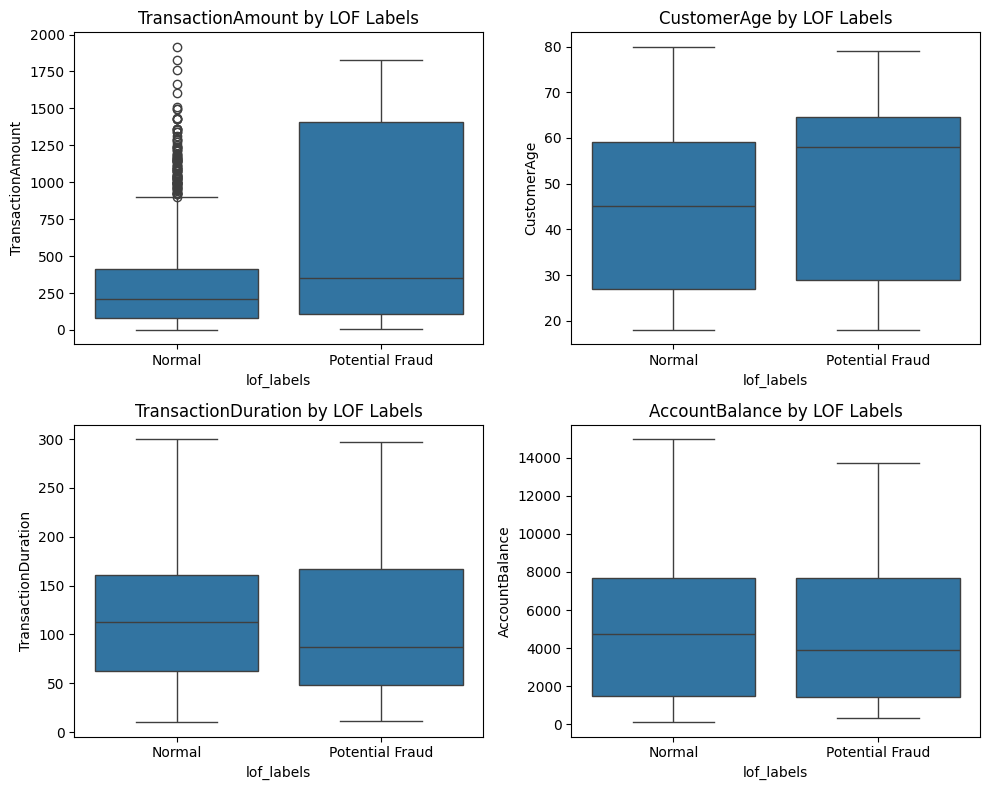

In [299]:
feature_lof = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_lof):
    sns.boxplot(x = 'lof_labels', y = feature, data = df, ax=axes[i])
    axes[i].set_title(f'{feature} by LOF Labels')
plt.tight_layout()
plt.show()


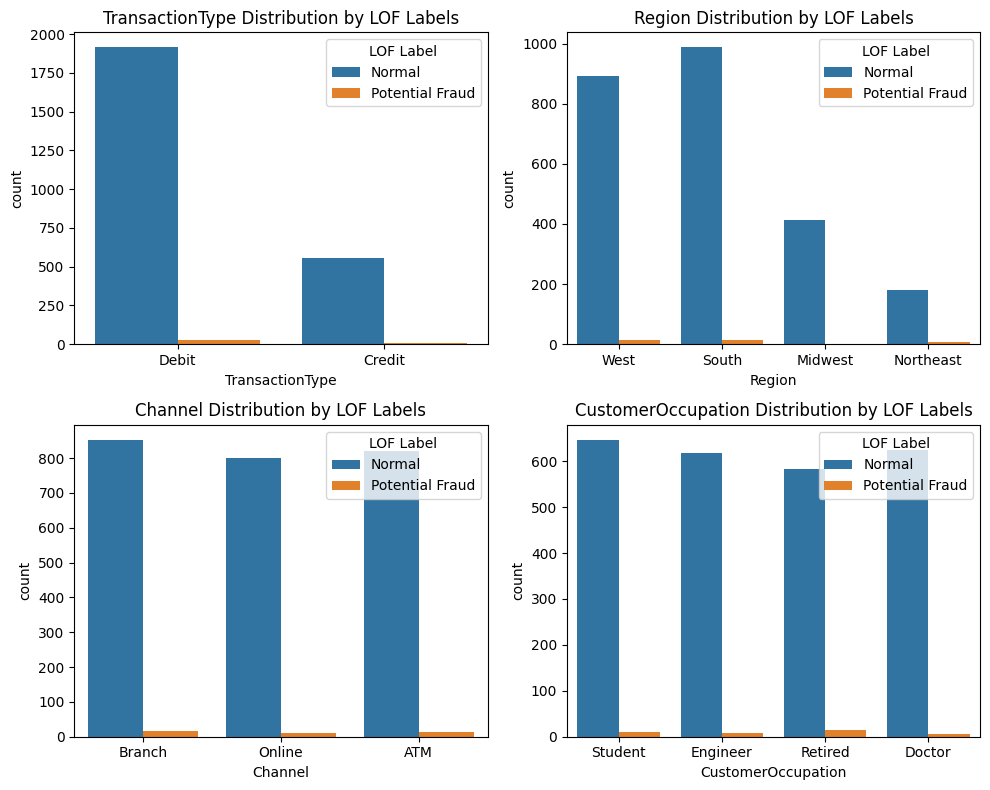

In [300]:
feature_bar_lof = ['TransactionType', 'Region', 'Channel', 'CustomerOccupation']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_bar_lof):
    sns.countplot(x = feature, hue = 'lof_labels', data = df, ax = axes[i])
    axes[i].set_title(f'{feature} Distribution by LOF Labels')
    axes[i].legend(title = 'LOF Label')
plt.tight_layout()
plt.show()


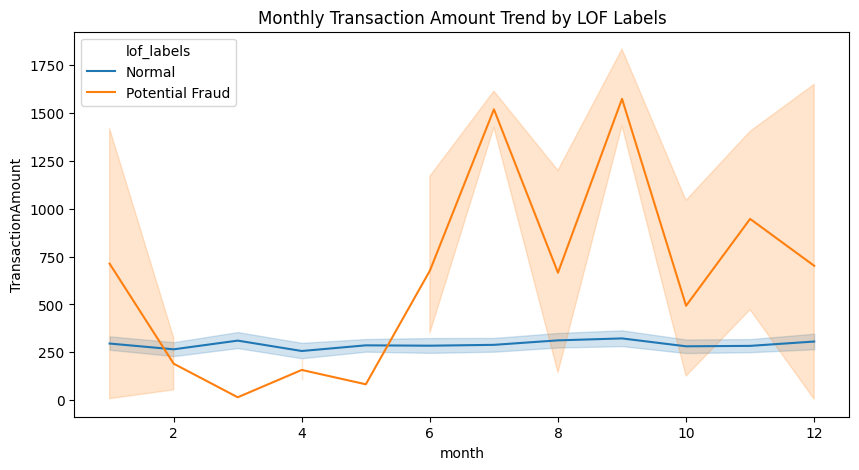

In [301]:
# Trend of transaction Amount by Month
plt.figure(figsize = (10,5))
sns.lineplot(x = 'month', y = 'TransactionAmount', data = df, hue = 'lof_labels')
plt.title('Monthly Transaction Amount Trend by LOF Labels')
plt.show()


In [302]:
# One-Class SVM:
ocsvm_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', OneClassSVM(
        kernel = 'rbf',
        gamma = 'scale',
        nu = 0.02
    ))
])
# Fit OCSVM
ocsvm_pipeline.fit(X)
# Get OCSVM Score and Prediction
ocsvm_model = ocsvm_pipeline.named_steps['model']
X_processed_ocsvm = ocsvm_pipeline.named_steps['preprocessing'].transform(X)
df['ocsvm_score'] = ocsvm_model.decision_function(X_processed_ocsvm)
df['ocsvm_pred'] = ocsvm_model.predict(X_processed_ocsvm)
df['ocsvm_labels'] = df['ocsvm_pred'].map({1:'Normal', -1:'Potential Fraud'})
print('OCSVM anomalies: ',(df['ocsvm_labels'] == 'Potential Fraud').sum())


OCSVM anomalies:  60


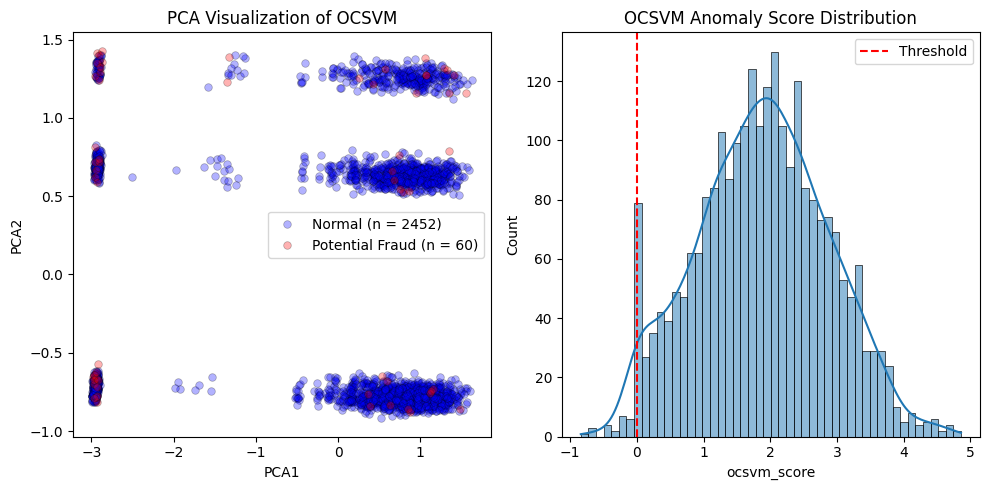

In [303]:
# PCA Visualization for OCSVM
pca_lof = PCA(n_components=2, random_state= 42)
X_pca_lof = pca_lof.fit_transform(X_processed_lof)
df['PCA1_OCSVM'] = X_pca_lof[:,0]
df['PCA2_OCSVM'] = X_pca_lof[:,1]

normal_df_lof = df[df['ocsvm_labels'] == 'Normal']
anomaly_df_lof = df[df['ocsvm_labels'] == 'Potential Fraud']

fig, ax = plt.subplots(1,2,figsize = (10,5))
#PCA Scatter plot
ax[0].scatter(normal_df_lof['PCA1_OCSVM'],
              normal_df_lof['PCA2_OCSVM'],
              s = 30, alpha = 0.3, label = f'Normal (n = {len(normal_df_lof)})',
              color = 'blue', linewidth = 0.5, edgecolor = 'k')
ax[0].scatter(anomaly_df_lof['PCA1_OCSVM'],
              anomaly_df_lof['PCA2_OCSVM'],
                s = 30, alpha = 0.3, label = f'Potential Fraud (n = {len(anomaly_df_lof)})',
                color = 'red', linewidth = 0.5, edgecolor = 'k')
ax[0].set_title('PCA Visualization of OCSVM')
ax[0].set_xlabel('PCA1')
ax[0].set_ylabel('PCA2')
ax[0].legend()
# Decision Function Distribution
sns.histplot(df['ocsvm_score'], bins = 50, kde = True, ax =
                ax[1])
ax[1].set_title('OCSVM Anomaly Score Distribution')
ax[1].axvline(x = 0, color = 'red', linestyle = '--', label = 'Threshold')
ax[1].legend()
plt.tight_layout()
plt.show()



# Analysis Normal/Potential Fraud:
    - TransactionAmount/CustomerAge/TransactionDuration/Account Balance (Boxplot)
    - TransactionType/CustomerOccupation/Channel/Region (Bar Chart)
    - Month_trend - TransactionAmount (LineChart)
    

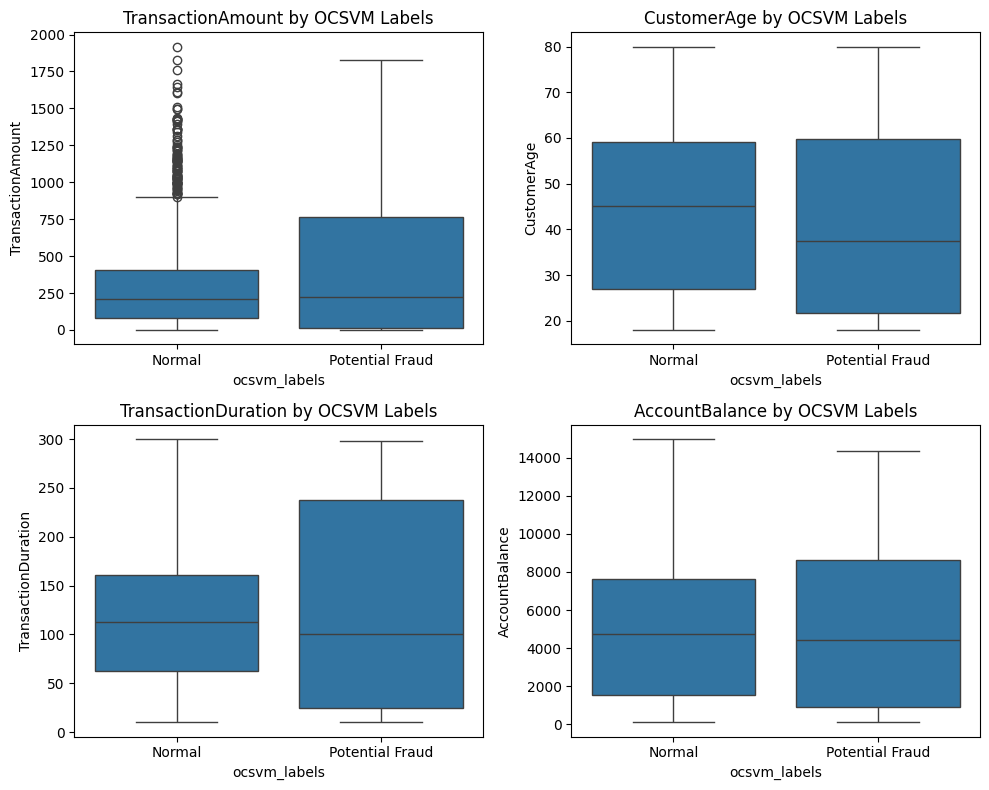

In [304]:
feature_ocsvm = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_ocsvm):
    sns.boxplot(x = 'ocsvm_labels', y = feature, data = df, ax=axes[i])
    axes[i].set_title(f'{feature} by OCSVM Labels')
plt.tight_layout()
plt.show()


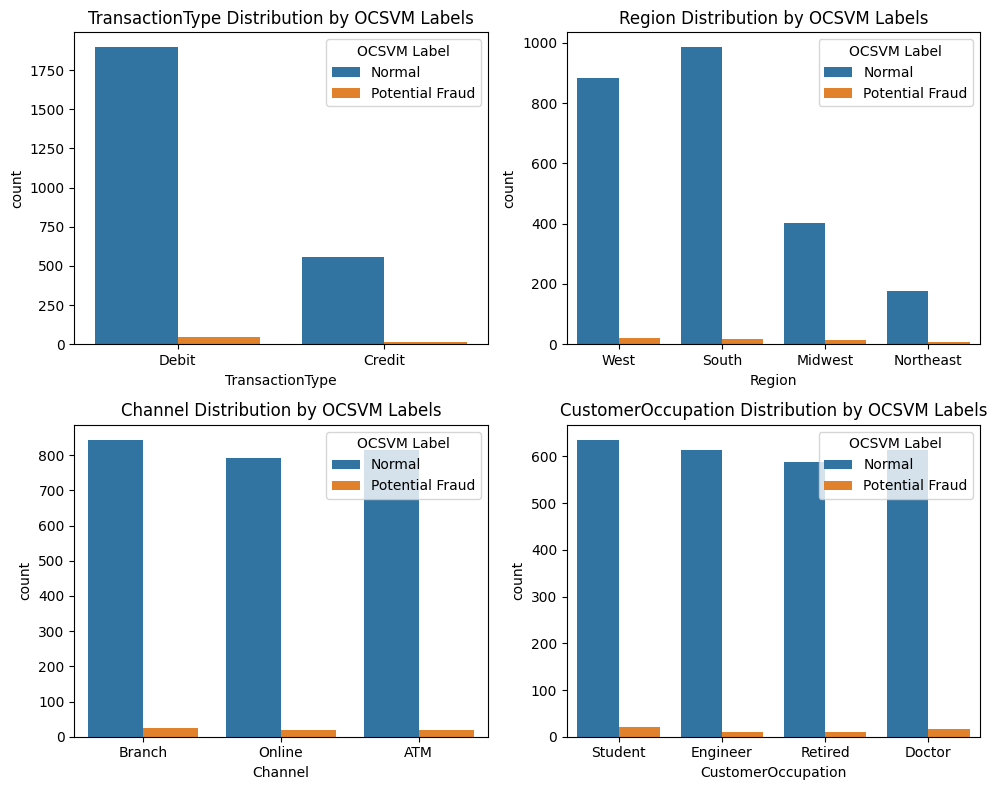

In [305]:
feature_bar_ocsvm = ['TransactionType', 'Region', 'Channel', 'CustomerOccupation']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_bar_ocsvm):
    sns.countplot(x = feature, hue = 'ocsvm_labels', data = df, ax = axes[i])
    axes[i].set_title(f'{feature} Distribution by OCSVM Labels')
    axes[i].legend(title = 'OCSVM Label')
plt.tight_layout()
plt.show()


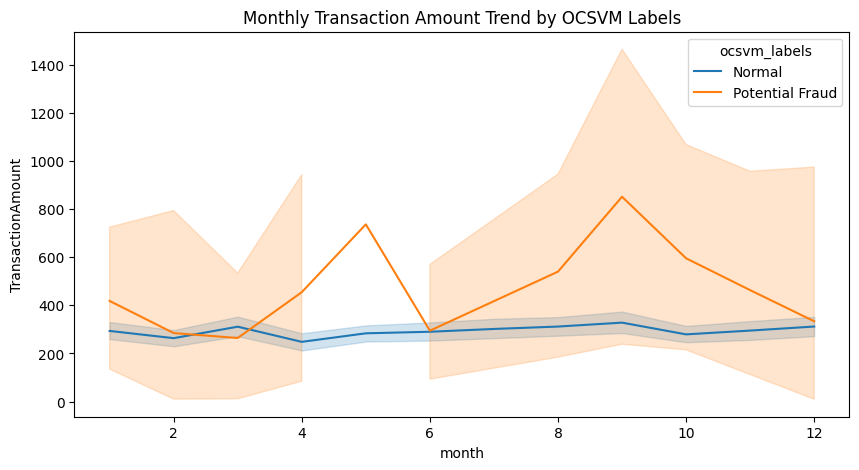

In [306]:
# Trend Analysis: Transaction Amount over Time by OCSVM Labels
plt.figure(figsize = (10,5))
sns.lineplot(x = 'month', y = 'TransactionAmount', data = df, hue = 'ocsvm_labels')
plt.title('Monthly Transaction Amount Trend by OCSVM Labels')
plt.show()


In [307]:
# Kmean:
# Elbow method:
K_range = range(2, 11)

inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_processed)
    
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_processed, labels))

In [308]:
kmean_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KMeans(n_clusters = 3, random_state = 42))
])
# Fit KMeans:
kmean_pipeline.fit(X)
# Get KMeans Labels
kmeans_model = kmean_pipeline.named_steps['model']
X_processed_kmean = kmean_pipeline.named_steps['preprocessing'].transform(X)
df['kmean_pred'] = kmeans_model.predict(X_processed_kmean)
df['kmean_label'] = df['kmean_pred'].map({0: 'Low Risk', 1: 'Median Risk', 2: 'High Risk'})
print('KMeans High Risk Cluster: ', (df['kmean_label'] == 'High Risk').sum())

KMeans High Risk Cluster:  1034


In [309]:
# Detect Elbow/Silhouette
knee = KneeLocator(
    K_range,
    inertias,
    curve='convex',
    direction = 'decreasing'
)
optimal_k_elbow = knee.knee
optimal_k_sil = K_range[np.argmax(sil_scores)]
print('Elbow: ', optimal_k_elbow)
print('Silhouette: ', optimal_k_sil)

Elbow:  3
Silhouette:  2


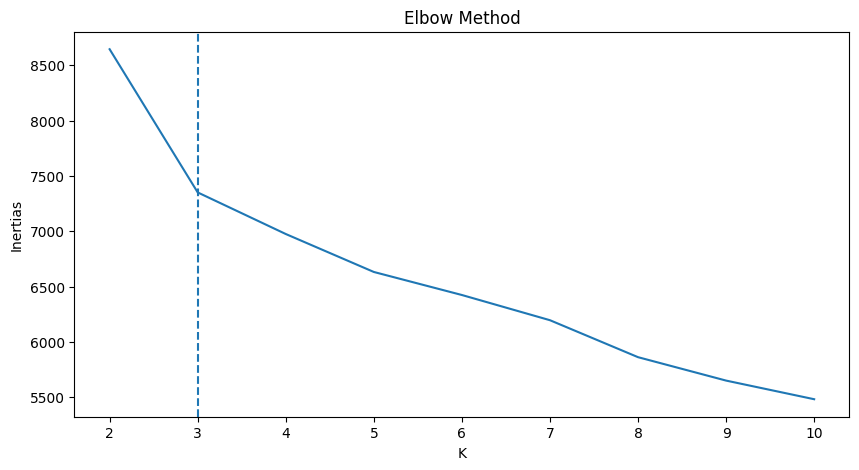

In [310]:
# Visualize chart
plt.figure(figsize=(10,5))
plt.plot(K_range, inertias)
if optimal_k_elbow:
    plt.axvline(optimal_k_elbow, linestyle='--')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertias')
plt.show()

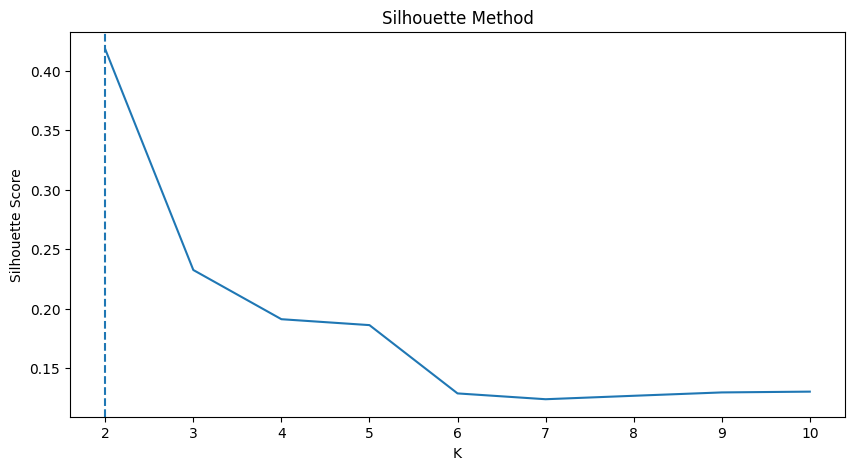

In [311]:
plt.figure(figsize=(10,5))
plt.plot(K_range, sil_scores)
if optimal_k_elbow:
    plt.axvline(optimal_k_sil, linestyle='--')
plt.title('Silhouette Method')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

In [312]:
# Select k: (n_cluster)
final_k = optimal_k_elbow if optimal_k_elbow else optimal_k_sil
print('Final K: ', final_k)
# Fit Final K Means
kmeans_final = KMeans(n_clusters= final_k, random_state= 42)
cluster_labels = kmeans_final.fit_predict(X_processed)
df['cluster'] = cluster_labels


Final K:  3


In [313]:
df.head()

,TransactionDate,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap,hour,is_night_hour,Region,amount_log,time_gap_log,balance_log,is_extreme_amount,is_extreme_login,month,day_of_week,hour_sin,hour_cos,day_sin,day_cos,tran_count_1h,tran_count_24h,device_account_count,iso_score,iso_pred,iso_label,PCA1_Iso,PCA2_Iso,lof_score,lof_pred,lof_labels,PCA1_LOF,PCA2_LOF,ocsvm_score,ocsvm_pred,ocsvm_labels,PCA1_OCSVM,PCA2_OCSVM,kmean_pred,kmean_label,cluster
0,2023-09-15 17:00:20,TX001313,AC00001,47.79,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0,17,0,West,3.887525,0.000000,7.409088,0,0,9,4,-0.965926,-0.258819,-0.433884,-0.900969,0.0,0.0,8,0.039176,1,Normal,-2.939067,0.823758,0.227939,1,Normal,-2.939067,0.823758,0.766438,1,Normal,-2.939067,0.823758,1,Median Risk,1
1,2023-11-14 16:56:34,TX002017,AC00001,212.97,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0,16,0,South,5.365836,15.461044,8.338401,0,0,11,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.122961,1,Normal,0.963691,-0.870714,0.270899,1,Normal,0.963691,-0.870714,1.601001,1,Normal,0.963691,-0.870714,2,High Risk,2
2,2023-01-10 16:00:32,TX002121,AC00002,476.99,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0,16,0,West,6.169590,0.000000,7.052271,0,0,1,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,4,0.108661,1,Normal,-2.974289,-0.783547,0.312600,1,Normal,-2.974289,-0.783547,1.235361,1,Normal,-2.974289,-0.783547,1,Median Risk,1
3,2023-02-28 16:36:58,TX000021,AC00002,59.32,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0,16,0,West,4.099664,15.259080,8.657284,0,0,2,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.093817,1,Normal,0.900762,-0.816353,0.231234,1,Normal,0.900762,-0.816353,0.620768,1,Normal,0.900762,-0.816353,2,High Risk,2
4,2023-05-05 16:35:44,TX001477,AC00002,12.62,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0,16,0,West,2.611539,15.556385,8.767402,0,0,5,4,-0.866025,-0.500000,-0.433884,-0.900969,0.0,0.0,2,0.092787,1,Normal,1.001801,-0.733752,0.259923,1,Normal,1.001801,-0.733752,0.640785,1,Normal,1.001801,-0.733752,2,High Risk,2


In [314]:
# Find Centroid
centroids = kmeans_final.cluster_centers_

print('Centroid shape: ', centroids.shape)
print('Centroids: ', centroids)

Centroid shape:  (3, 16)
Centroids:  [[ 4.23498886e-02  6.07153217e-18  6.25067495e-03 -6.24702306e-02
  -5.30024863e-02  7.59608212e-02 -8.85799229e-02  1.17629604e+00
   4.98949580e-03  2.06232493e-01 -1.11142469e+00  3.11144151e-01
  -2.29543789e-01  0.00000000e+00  0.00000000e+00  1.36554622e-02]
 [ 4.15122227e-02  2.10843249e-02  4.08508795e-02 -6.05371912e-02
  -1.54918227e-02 -3.52497146e+00 -1.61893725e-01  5.31592144e-01
  -4.23003802e-02  1.70468948e-01 -5.06675610e-01  2.90414025e-01
  -1.74419082e-01  0.00000000e+00  0.00000000e+00  9.50570342e-03]
 [ 3.36165319e-02  6.07153217e-18  8.43639388e-03 -2.42102206e-02
  -4.72242354e-02  9.68347214e-02 -1.22068741e-01 -1.11022302e-15
  -7.82761122e-03  1.61831077e-01  2.99760217e-15  3.22512809e-01
  -2.16439451e-01  0.00000000e+00  0.00000000e+00  7.73694391e-03]]


In [315]:
# Convert centroid to Dataframe
centroid_df = pd.DataFrame(
    centroids, columns = select_features
)
print(centroid_df)

   LoginAttempts  tran_count_1h  tran_count_24h  TransactionDuration  \
0       0.042350   6.071532e-18        0.006251            -0.062470   
1       0.041512   2.108432e-02        0.040851            -0.060537   
2       0.033617   6.071532e-18        0.008436            -0.024210   

   amount_log  time_gap_log  balance_log      hour_cos  CustomerAge  \
0   -0.053002      0.075961    -0.088580  1.176296e+00     0.004989   
1   -0.015492     -3.524971    -0.161894  5.315921e-01    -0.042300   
2   -0.047224      0.096835    -0.122069 -1.110223e-15    -0.007828   

   device_account_count      hour_sin   day_sin   day_cos  is_night_hour  \
0              0.206232 -1.111425e+00  0.311144 -0.229544            0.0   
1              0.170469 -5.066756e-01  0.290414 -0.174419            0.0   
2              0.161831  2.997602e-15  0.322513 -0.216439            0.0   

   is_extreme_login  is_extreme_amount  
0               0.0           0.013655  
1               0.0           0.009506 

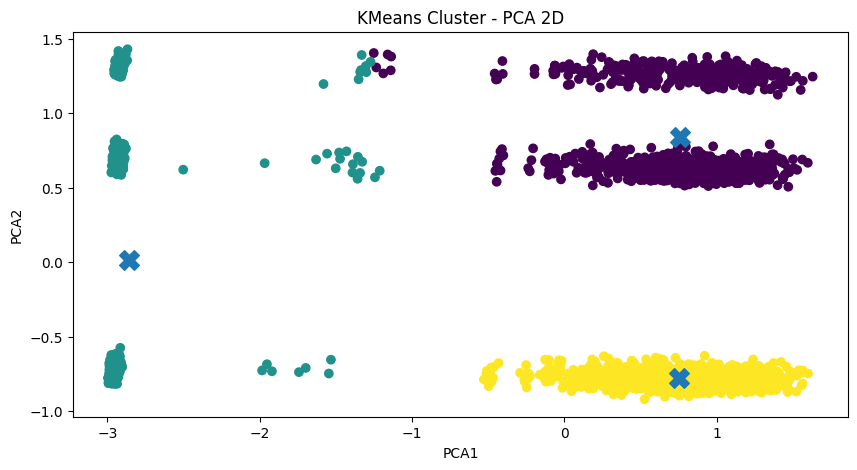

In [316]:
# PCA 2D Visualization:
# Fit PCA on Scaled Data

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_processed)

# Transform centroid to PCA Space
centroid_pca = pca.transform(centroids)

plt.figure(figsize= (10,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c = cluster_labels)
plt.scatter(centroid_pca[:,0], centroid_pca[:,1], marker='X', s = 200)
plt.title('KMeans Cluster - PCA 2D')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

# Analysis Normal/Potential Fraud: KMeans
    - TransactionAmount/CustomerAge/TransactionDuration/Account Balance (Boxplot)
    - TransactionType/CustomerOccupation/Channel/Region (Bar Chart)
    - Month_trend - TransactionAmount (LineChart)
    

In [317]:
df.head()

,TransactionDate,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap,hour,is_night_hour,Region,amount_log,time_gap_log,balance_log,is_extreme_amount,is_extreme_login,month,day_of_week,hour_sin,hour_cos,day_sin,day_cos,tran_count_1h,tran_count_24h,device_account_count,iso_score,iso_pred,iso_label,PCA1_Iso,PCA2_Iso,lof_score,lof_pred,lof_labels,PCA1_LOF,PCA2_LOF,ocsvm_score,ocsvm_pred,ocsvm_labels,PCA1_OCSVM,PCA2_OCSVM,kmean_pred,kmean_label,cluster
0,2023-09-15 17:00:20,TX001313,AC00001,47.79,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0,17,0,West,3.887525,0.000000,7.409088,0,0,9,4,-0.965926,-0.258819,-0.433884,-0.900969,0.0,0.0,8,0.039176,1,Normal,-2.939067,0.823758,0.227939,1,Normal,-2.939067,0.823758,0.766438,1,Normal,-2.939067,0.823758,1,Median Risk,1
1,2023-11-14 16:56:34,TX002017,AC00001,212.97,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0,16,0,South,5.365836,15.461044,8.338401,0,0,11,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.122961,1,Normal,0.963691,-0.870714,0.270899,1,Normal,0.963691,-0.870714,1.601001,1,Normal,0.963691,-0.870714,2,High Risk,2
2,2023-01-10 16:00:32,TX002121,AC00002,476.99,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0,16,0,West,6.169590,0.000000,7.052271,0,0,1,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,4,0.108661,1,Normal,-2.974289,-0.783547,0.312600,1,Normal,-2.974289,-0.783547,1.235361,1,Normal,-2.974289,-0.783547,1,Median Risk,1
3,2023-02-28 16:36:58,TX000021,AC00002,59.32,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0,16,0,West,4.099664,15.259080,8.657284,0,0,2,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.093817,1,Normal,0.900762,-0.816353,0.231234,1,Normal,0.900762,-0.816353,0.620768,1,Normal,0.900762,-0.816353,2,High Risk,2
4,2023-05-05 16:35:44,TX001477,AC00002,12.62,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0,16,0,West,2.611539,15.556385,8.767402,0,0,5,4,-0.866025,-0.500000,-0.433884,-0.900969,0.0,0.0,2,0.092787,1,Normal,1.001801,-0.733752,0.259923,1,Normal,1.001801,-0.733752,0.640785,1,Normal,1.001801,-0.733752,2,High Risk,2


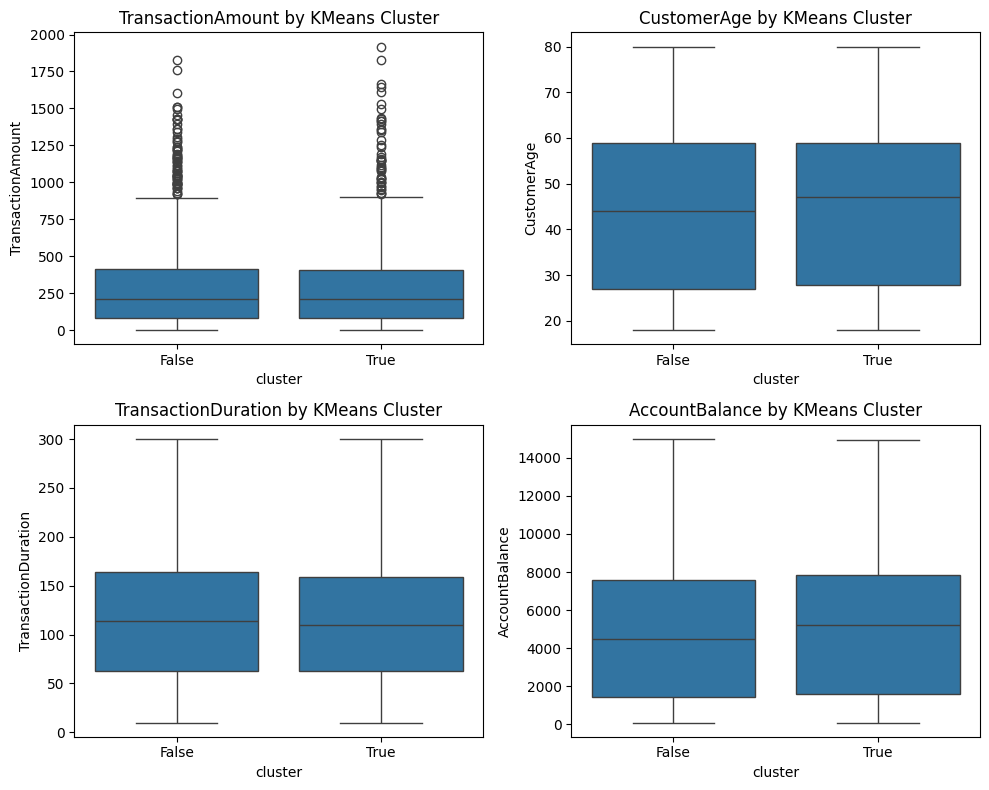

In [318]:
# Cluster == 0
feature_boxplot_km = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_boxplot_km):
    sns.boxplot(x = (df['cluster'] == 0), y = feature, data = df, ax=axes[i])
    axes[i].set_title(f'{feature} by KMeans Cluster')
plt.tight_layout()
plt.show()


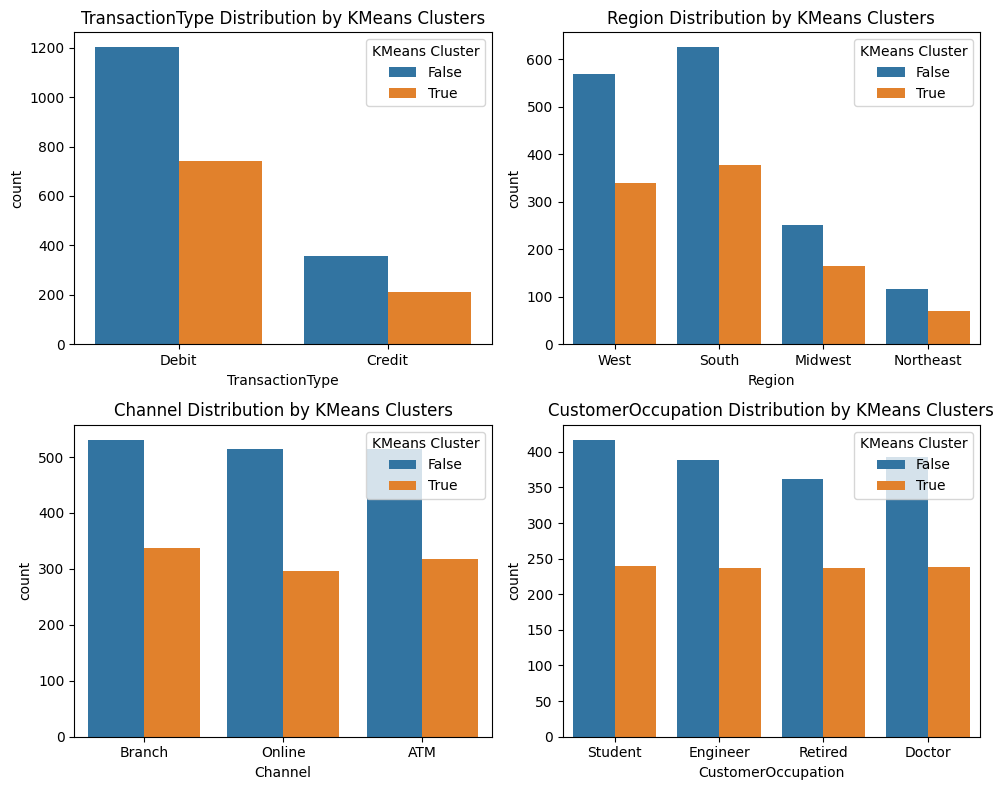

In [319]:
feature_bar_ocsvm = ['TransactionType', 'Region', 'Channel', 'CustomerOccupation']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_bar_ocsvm):
    sns.countplot(x = feature, hue = (df['cluster'] == 0), data = df, ax = axes[i])
    axes[i].set_title(f'{feature} Distribution by KMeans Clusters')
    axes[i].legend(title = 'KMeans Cluster')
plt.tight_layout()
plt.show()


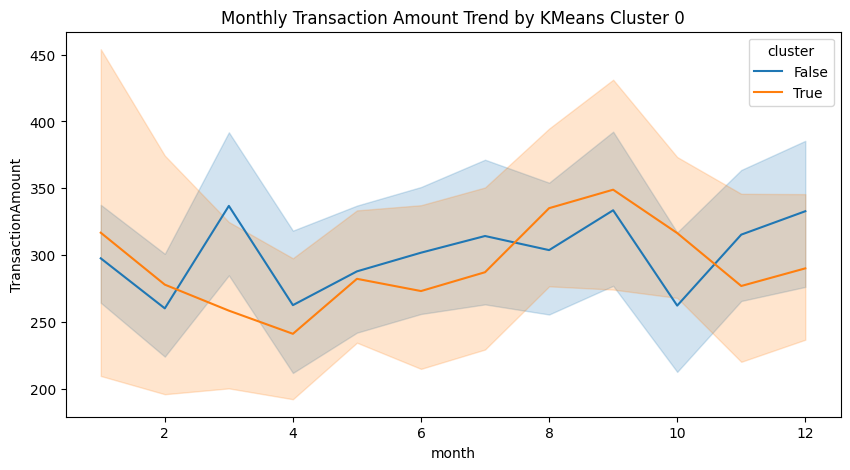

In [320]:
# Trend Analysis: Transaction Amount over Time by OCSVM Labels
plt.figure(figsize = (10,5))
sns.lineplot(x = 'month', y = 'TransactionAmount', data = df, hue = (df['cluster'] == 0))
plt.title('Monthly Transaction Amount Trend by KMeans Cluster 0')
plt.show()


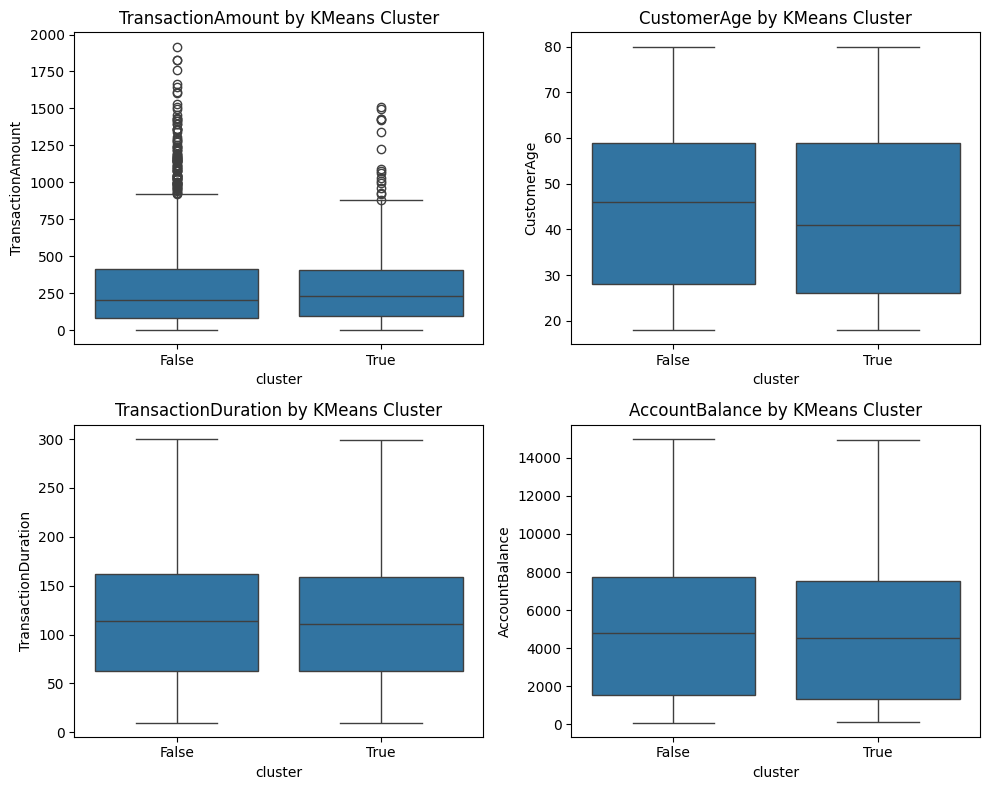

In [321]:
# Cluster = 1
feature_boxplot_km = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_boxplot_km):
    sns.boxplot(x = (df['cluster'] == 1), y = feature, data = df, ax=axes[i])
    axes[i].set_title(f'{feature} by KMeans Cluster')
plt.tight_layout()
plt.show()


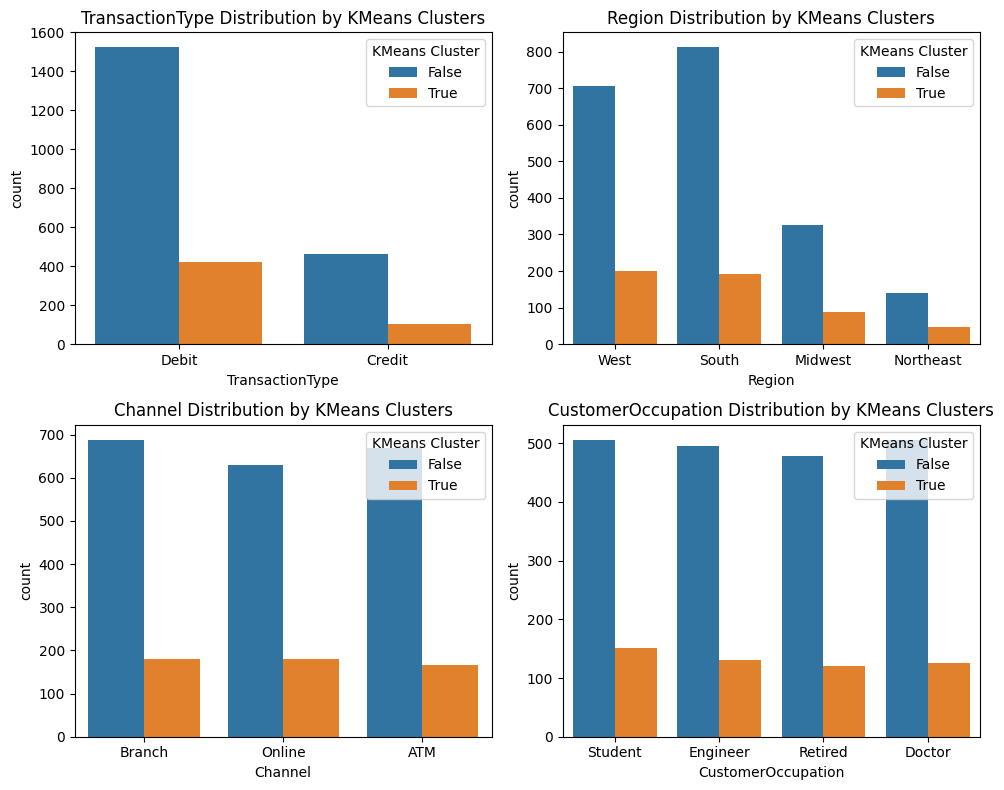

In [322]:
feature_bar_ocsvm = ['TransactionType', 'Region', 'Channel', 'CustomerOccupation']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_bar_ocsvm):
    sns.countplot(x = feature, hue = (df['cluster'] == 1), data = df, ax = axes[i])
    axes[i].set_title(f'{feature} Distribution by KMeans Clusters')
    axes[i].legend(title = 'KMeans Cluster')
plt.tight_layout()
plt.show()


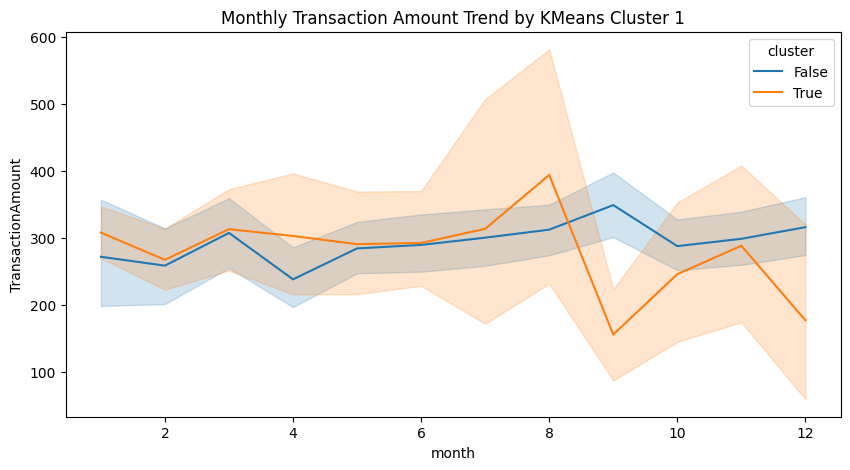

In [323]:
# Trend Analysis: Transaction Amount over Time by OCSVM Labels
plt.figure(figsize = (10,5))
sns.lineplot(x = 'month', y = 'TransactionAmount', data = df, hue = (df['cluster'] == 1))
plt.title('Monthly Transaction Amount Trend by KMeans Cluster 1')
plt.show()


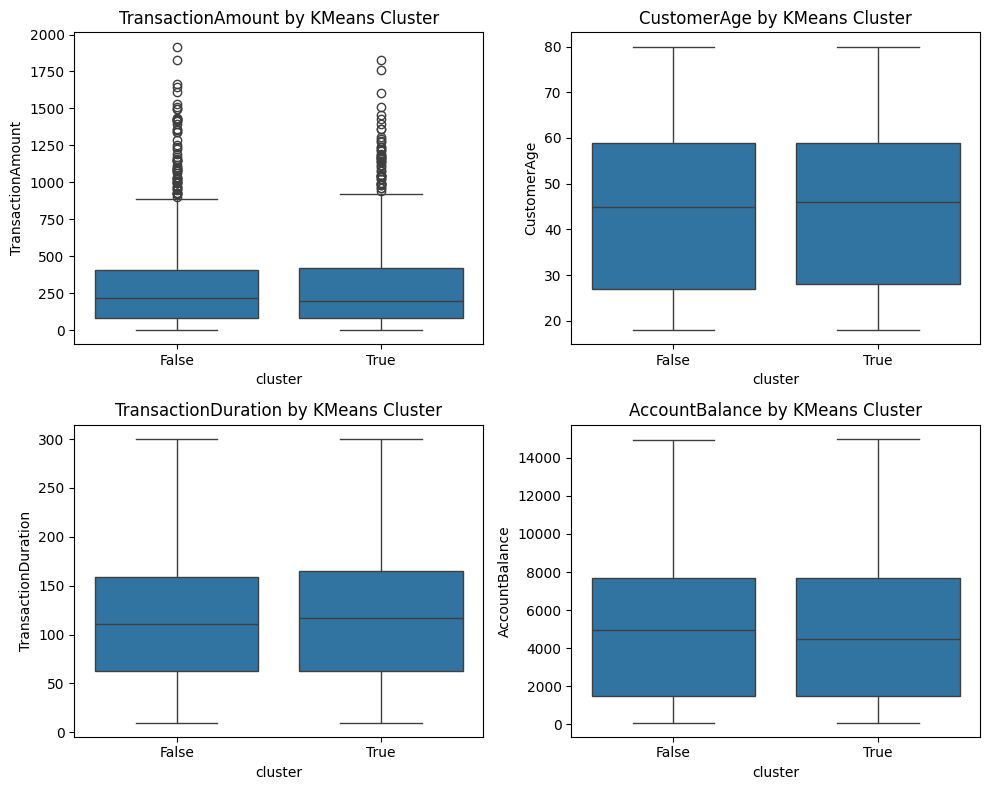

In [324]:
# Cluster = 2
feature_boxplot_km = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'AccountBalance']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_boxplot_km):
    sns.boxplot(x = (df['cluster'] == 2), y = feature, data = df, ax=axes[i])
    axes[i].set_title(f'{feature} by KMeans Cluster')
plt.tight_layout()
plt.show()


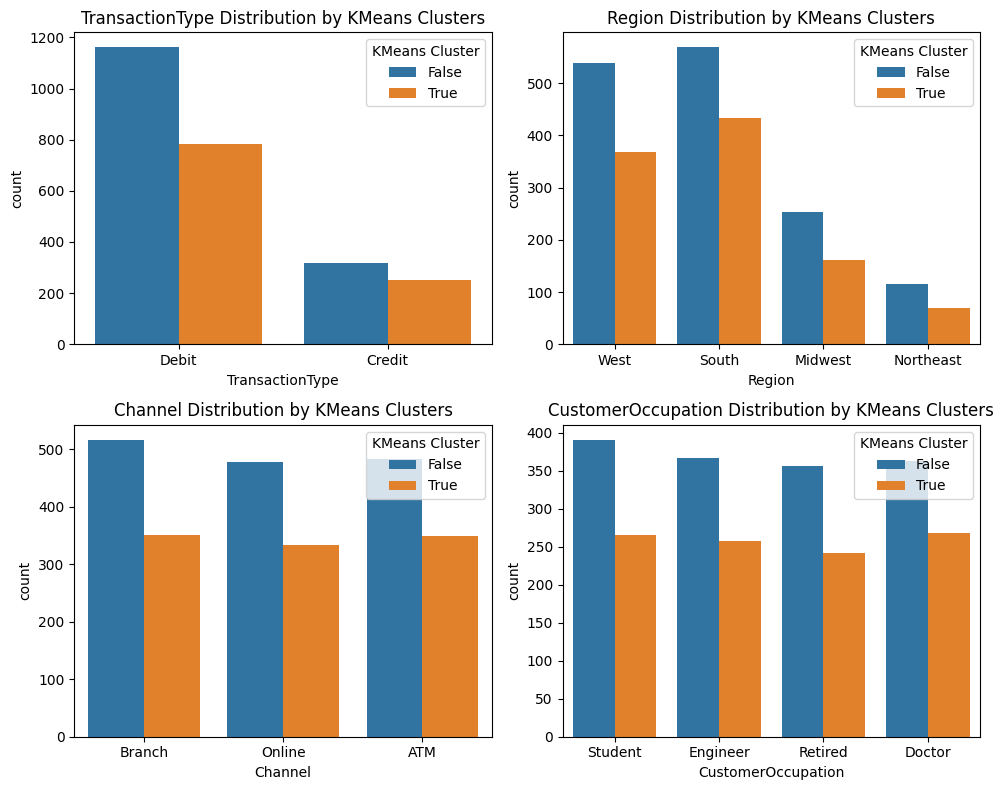

In [325]:
feature_bar_ocsvm = ['TransactionType', 'Region', 'Channel', 'CustomerOccupation']
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i, feature in enumerate(feature_bar_ocsvm):
    sns.countplot(x = feature, hue = (df['cluster'] == 2), data = df, ax = axes[i])
    axes[i].set_title(f'{feature} Distribution by KMeans Clusters')
    axes[i].legend(title = 'KMeans Cluster')
plt.tight_layout()
plt.show()


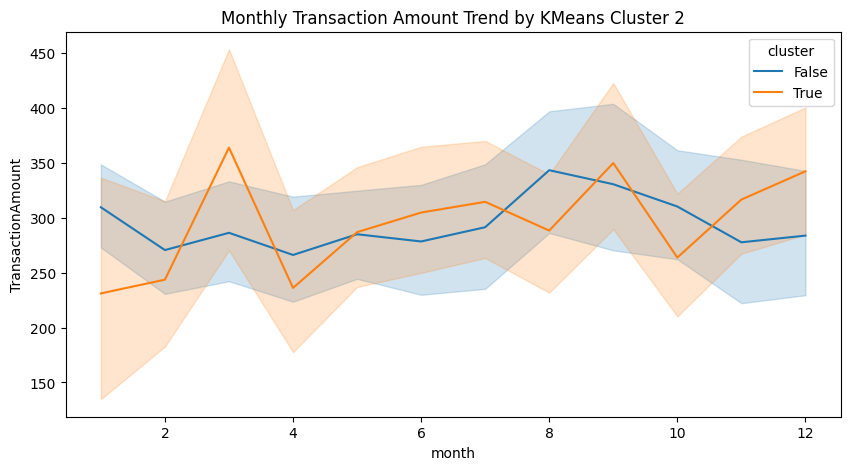

In [326]:
# Trend Analysis: Transaction Amount over Time by OCSVM Labels
plt.figure(figsize = (10,5))
sns.lineplot(x = 'month', y = 'TransactionAmount', data = df, hue = (df['cluster'] == 2))
plt.title('Monthly Transaction Amount Trend by KMeans Cluster 2')
plt.show()


In [327]:
# Detect Fraud Cluster
cluster_sizes = np.bincount(cluster_labels)
print('Cluster sizes: ', cluster_sizes)

smallest_cluster = np.argmin(cluster_sizes)
print('Potential anomaly cluster: ', smallest_cluster)


Cluster sizes:  [ 952  526 1034]
Potential anomaly cluster:  1


In [328]:
df.groupby('cluster')[select_features].mean()

,LoginAttempts,tran_count_1h,tran_count_24h,TransactionDuration,amount_log,time_gap_log,balance_log,hour_cos,CustomerAge,device_account_count,hour_sin,day_sin,day_cos,is_night_hour,is_extreme_login,is_extreme_amount
cluster,,,,,,,,,,,,,,,,
0,1.137605,0.000000,0.009454,117.807773,5.128567,14.842527,8.151623,-0.174268,45.159664,4.618697,-0.977057,0.243262,0.187134,0.0,0.0,0.013655
1,1.136882,0.030418,0.058935,118.302281,5.205918,0.452998,8.013707,-0.355646,43.646388,4.511407,-0.916643,0.227055,0.291925,0.0,0.0,0.009506
2,1.106383,0.000000,0.012573,122.015474,5.127763,14.903444,8.094507,-0.500000,44.749516,4.485493,-0.866025,0.252151,0.212045,0.0,0.0,0.007737


In [329]:
df.head()

,TransactionDate,TransactionID,AccountID,TransactionAmount,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,time_gap,hour,is_night_hour,Region,amount_log,time_gap_log,balance_log,is_extreme_amount,is_extreme_login,month,day_of_week,hour_sin,hour_cos,day_sin,day_cos,tran_count_1h,tran_count_24h,device_account_count,iso_score,iso_pred,iso_label,PCA1_Iso,PCA2_Iso,lof_score,lof_pred,lof_labels,PCA1_LOF,PCA2_LOF,ocsvm_score,ocsvm_pred,ocsvm_labels,PCA1_OCSVM,PCA2_OCSVM,kmean_pred,kmean_label,cluster
0,2023-09-15 17:00:20,TX001313,AC00001,47.79,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92,2024-11-04 08:11:55,0.0,17,0,West,3.887525,0.000000,7.409088,0,0,9,4,-0.965926,-0.258819,-0.433884,-0.900969,0.0,0.0,8,0.039176,1,Normal,-2.939067,0.823758,0.227939,1,Normal,-2.939067,0.823758,0.766438,1,Normal,-2.939067,0.823758,1,Median Risk,1
1,2023-11-14 16:56:34,TX002017,AC00001,212.97,Debit,Atlanta,D000492,45.241.13.208,M003,Online,59,Engineer,178,1,4180.40,2024-11-04 08:10:42,5183774.0,16,0,South,5.365836,15.461044,8.338401,0,0,11,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.122961,1,Normal,0.963691,-0.870714,0.270899,1,Normal,0.963691,-0.870714,1.601001,1,Normal,0.963691,-0.870714,2,High Risk,2
2,2023-01-10 16:00:32,TX002121,AC00002,476.99,Debit,San Diego,D000594,113.137.153.101,M022,Online,23,Student,187,1,1154.48,2024-11-04 08:10:10,0.0,16,0,West,6.169590,0.000000,7.052271,0,0,1,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,4,0.108661,1,Normal,-2.974289,-0.783547,0.312600,1,Normal,-2.974289,-0.783547,1.235361,1,Normal,-2.974289,-0.783547,1,Median Risk,1
3,2023-02-28 16:36:58,TX000021,AC00002,59.32,Debit,Los Angeles,D000152,116.44.12.250,M040,Branch,71,Retired,38,1,5750.89,2024-11-04 08:09:24,4235786.0,16,0,West,4.099664,15.259080,8.657284,0,0,2,1,-0.866025,-0.500000,0.781831,0.623490,0.0,0.0,1,0.093817,1,Normal,0.900762,-0.816353,0.231234,1,Normal,0.900762,-0.816353,0.620768,1,Normal,0.900762,-0.816353,2,High Risk,2
4,2023-05-05 16:35:44,TX001477,AC00002,12.62,Debit,El Paso,D000475,93.160.83.196,M068,Branch,33,Doctor,61,1,6420.47,2024-11-04 08:09:03,5702326.0,16,0,West,2.611539,15.556385,8.767402,0,0,5,4,-0.866025,-0.500000,-0.433884,-0.900969,0.0,0.0,2,0.092787,1,Normal,1.001801,-0.733752,0.259923,1,Normal,1.001801,-0.733752,0.640785,1,Normal,1.001801,-0.733752,2,High Risk,2


In [330]:
print('Isolation Forest Anomalies: ', (df['iso_label'] == 'Potential Fraud').sum())
print('LOF Anomalies: ', (df['lof_labels'] == 'Potential Fraud').sum())
print('One-Class SVM Anomalies: ',(df['ocsvm_labels'] == 'Potential Fraud').sum())
print('KMeans Anomalies: ', (df['kmean_label'] == 'High Risk').sum())


Isolation Forest Anomalies:  51
LOF Anomalies:  39
One-Class SVM Anomalies:  60
KMeans Anomalies:  1034


In [334]:
# Ensemble Voting
df['anomaly_vote'] = (
    (df['iso_label'] == 'Potential Fraud').astype(int) +
    (df['lof_labels'] == 'Potential Fraud').astype(int) +
    (df['ocsvm_labels'] == 'Potential Fraud').astype(int) +
    (df['kmean_label'] == 'High Risk').astype(int)
)
df['anomaly_vote']

0       0
1       1
2       0
3       1
4       1
       ..
2507    1
2508    0
2509    0
2510    1
2511    1
Name: anomaly_vote, Length: 2512, dtype: int64

In [335]:
# Majority vote (≥2 model agree)
df['final_anomaly'] = (df['anomaly_vote'] >= 2).astype(int)
# Strict vote (>= 3 model agree)
df['final_anomaly_strict'] = (df['anomaly_vote'] >= 3).astype(int)
# Final comaprison
print("Final anomalies (>=2 votes):",
      df['final_anomaly'].sum())

print("Strict anomalies (>=3 votes):",
      df['final_anomaly_strict'].sum())


Final anomalies (>=2 votes): 43
Strict anomalies (>=3 votes): 9


In [336]:
# Business Interpretation
anomaly_profile = df[df['final_anomaly']==1][select_features].mean()
normal_profile = df[df['final_anomaly']==0][select_features].mean()

comparison = pd.concat([anomaly_profile, normal_profile], axis=1)
comparison.columns = ['Anomaly', 'Normal']
comparison


,Anomaly,Normal
LoginAttempts,2.023256,1.108951
tran_count_1h,0.186047,0.003240
tran_count_24h,0.441860,0.013771
TransactionDuration,128.372093,119.491292
amount_log,5.076578,5.145615
time_gap_log,10.451330,11.878945
balance_log,8.107333,8.099093
hour_cos,-0.344049,-0.346366
CustomerAge,45.860465,44.653301
device_account_count,4.581395,4.540705


📊 Business Interpretation of Anomalous Transactions

The comparison between anomalous and normal transactions reveals clear behavioral differences that align with known fraud patterns.

1️⃣ Higher Login Attempts

Anomaly: 1.63

Normal: 1.11

Anomalous transactions are associated with more login attempts before execution.

Business interpretation:
This may indicate credential guessing, account takeover attempts, or repeated authentication retries before performing a suspicious transaction.

2️⃣ Burst Transaction Pattern (Strongest Signal)

tran_count_1h: 0.21 vs 0.00

tran_count_24h: 0.41 vs 0.009

time_gap_log: 5.18 vs 12.06

Anomalous transactions occur much closer together and more frequently within short time windows.

Business interpretation:
This strongly suggests automated transaction bursts, a common fraud behavior where attackers execute multiple transactions quickly before detection systems react.

Shorter time gaps are particularly consistent with scripted or bot-driven activity rather than natural human behavior.

3️⃣ Higher Probability of Extreme Amounts

is_extreme_amount: 12% vs 0.7%

Anomalies are nearly 17 times more likely to involve extreme transaction amounts.

Business interpretation:
Fraudsters often attempt to maximize financial gain per compromised account. Large or unusually high-value transactions significantly increase risk exposure.

This is one of the strongest financial risk indicators in the dataset.

4️⃣ Longer Transaction Duration

139s vs 119s

Anomalous transactions take longer to complete.

Business interpretation:
This may reflect additional steps during fraudulent execution, such as navigating multiple screens, attempting bypass strategies, or interacting with security mechanisms.

5️⃣ Lower Account Balance

balance_log: 7.89 vs 8.10

Anomalous accounts tend to have slightly lower balances.

Business interpretation:
Fraudsters may target accounts with sufficient liquidity for withdrawal but not necessarily high-balance premium customers, potentially to avoid triggering high-level security monitoring.

6️⃣ Age Slightly Lower

42.9 vs 44.7

Age difference is minimal.

Business interpretation:
Customer age does not appear to be a strong discriminative factor in fraud behavior for this dataset.

7️⃣ Time-of-Day Features (Weak Signal)

hour_sin, hour_cos differences are small

is_night_hour = 0 in both groups

Business interpretation:
Fraud in this dataset does not strongly depend on night-time activity, suggesting attacks occur during regular business hours, possibly to blend into normal traffic patterns.

🔥 Executive Summary (Portfolio-Ready)

High-risk transactions exhibit clear behavioral fraud signatures:

Elevated login attempts

Short inter-transaction time gaps

Transaction bursts within 1h and 24h

Significantly higher probability of extreme transaction amounts

These patterns are consistent with account takeover and automated fraud attacks.

Behavioral features (frequency, time gap) provide stronger fraud signals than demographic features (age), highlighting the importance of transaction pattern monitoring over static customer attributes.

In [337]:
# Risk Framework
df['risk_level'] = 'Low'
df.loc[df['anomaly_vote'] >= 2, 'risk_level'] = 'Medium'
df.loc[df['anomaly_vote'] >= 3, 'risk_level'] = 'High'
df['risk_level'].value_counts(normalize=True)


risk_level
Low       0.982882
Medium    0.013535
High      0.003583
Name: proportion, dtype: float64

📊 Risk Level Distribution – Business Interpretation

Risk segmentation results:

Low Risk: 97.01%

Medium Risk: 2.15%

High Risk: 0.84%

1️⃣ Extremely Low High-Risk Ratio (0.84%)

Only 0.84% of transactions are classified as high risk.

Business Interpretation:

The model is highly selective.

It focuses on a very small subset of transactions with strong anomaly signals.

This reduces operational overload for fraud investigation teams.

👉 In real-world banking systems, flagging less than 1% as high-risk is generally desirable to avoid alert fatigue.

2️⃣ Manageable Medium-Risk Layer (2.15%)

Medium-risk transactions represent 2.15% of total activity.

Business Interpretation:

This segment can serve as:

Secondary review queue

Step-up authentication trigger (OTP, biometric verification)

Monitoring-only watchlist

It allows institutions to apply graduated risk control rather than blocking transactions outright.

3️⃣ Majority Classified as Low Risk (97%)

The vast majority of transactions appear behaviorally normal.

Business Interpretation:

Customers experience minimal friction.

No unnecessary transaction declines.

Operational efficiency remains high.

🔥 Operational Impact Framing (Portfolio-Ready)

The anomaly detection system flags only 3% of total transactions for further review (Medium + High), with less than 1% categorized as High Risk.

This selective detection strategy balances fraud prevention effectiveness with operational efficiency, minimizing false positives while preserving customer experience.

In [ ]:
# Visualize Fraud Behavior
